# ARM Server vs x86 Lockbench Comparison

Comparing `arm_xgene1_lockbench.csv` (X-Gene 1, ARMv8) against `x86_xeon_lockbench.csv` (Intel Xeon).
Shared thread range: 1–8. x86 also has 16 and 32 threads.

**Locks:** TAS, TTAS, CAS, Ticket, RW, OCC, RCU, Lock
**Workloads:** mutex (write-only), rw (mixed reads), rcu (read-heavy)

In [ ]:
from pathlib import Path
from IPython.display import display

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

INT_COLS   = ['threads', 'cs_work', 'read_pct', 'total_ops', 'read_ops', 'write_ops']
FLOAT_COLS = ['ops_s', 'ns_op', 'fairness_min', 'fairness_max', 'fairness_ratio']

def resolve_csv(name):
    # Notebook lives in results/archive/, so search the archive dir, then results/, then cwd.
    for base in [Path('.'), Path('..'), Path('../results'), Path('results')]:
        p = base / name
        if p.exists():
            return p
    raise FileNotFoundError(name)

def load_csv(path, platform):
    df = pd.read_csv(path, sep=';', decimal=',')
    for c in INT_COLS:
        df[c] = pd.to_numeric(df[c], errors='coerce').astype('Int64')
    for c in FLOAT_COLS:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df['ops_s'] = df['ops_s'].astype(float)
    df['ops_m']    = df['ops_s'] / 1e6
    df['platform'] = platform
    return df

arm = load_csv(resolve_csv('arm_xgene1_lockbench.csv'), 'arm')
x86 = load_csv(resolve_csv('x86_xeon_lockbench.csv'),   'x86')
all_df = pd.concat([arm, x86], ignore_index=True)

SHARED_THREADS = sorted(set(arm['threads'].dropna().astype(int).unique()) &
                        set(x86['threads'].dropna().astype(int).unique()))

def agg(df, group_cols):
    return (
        df.groupby(group_cols)
          .agg(
              runs        = ('ops_m', 'size'),
              ops_m_mean  = ('ops_m',           'mean'),
              ops_m_std   = ('ops_m',           'std'),
              ns_mean     = ('ns_op',           'mean'),
              fair_mean   = ('fairness_ratio',  'mean'),
              fair_std    = ('fairness_ratio',  'std'),
          )
          .reset_index()
    )

LOCK_ORDER  = ['tas', 'ttas', 'cas', 'ticket', 'rw', 'occ', 'rcu', 'lock']
LOCK_LABELS = {'tas':'TAS','ttas':'TTAS','cas':'CAS','ticket':'Ticket',
               'rw':'RW','occ':'OCC','rcu':'RCU','lock':'Lock'}
LOCK_COLORS = {'tas':'#4e79a7','ttas':'#f28e2b','cas':'#e15759','ticket':'#76b7b2',
               'rw':'#59a14f','occ':'#af7aa1','rcu':'#ff9da7','lock':'#9c755f'}

PLAT_COLORS = {'arm': '#2ca02c', 'x86': '#1f77b4'}
PLAT_LABELS = {'arm': 'ARM Server', 'x86': 'Intel x86'}
PLAT_MARKER = {'arm': 's', 'x86': 'o'}

print('ARM threads  :', sorted(arm['threads'].dropna().astype(int).unique()))
print('x86 threads  :', sorted(x86['threads'].dropna().astype(int).unique()))
print('Shared threads:', SHARED_THREADS)
print('ARM locks    :', sorted(arm['lock'].unique()))
print('x86 locks    :', sorted(x86['lock'].unique()))

## 1. Mutex Workload — Throughput (shared thread range)

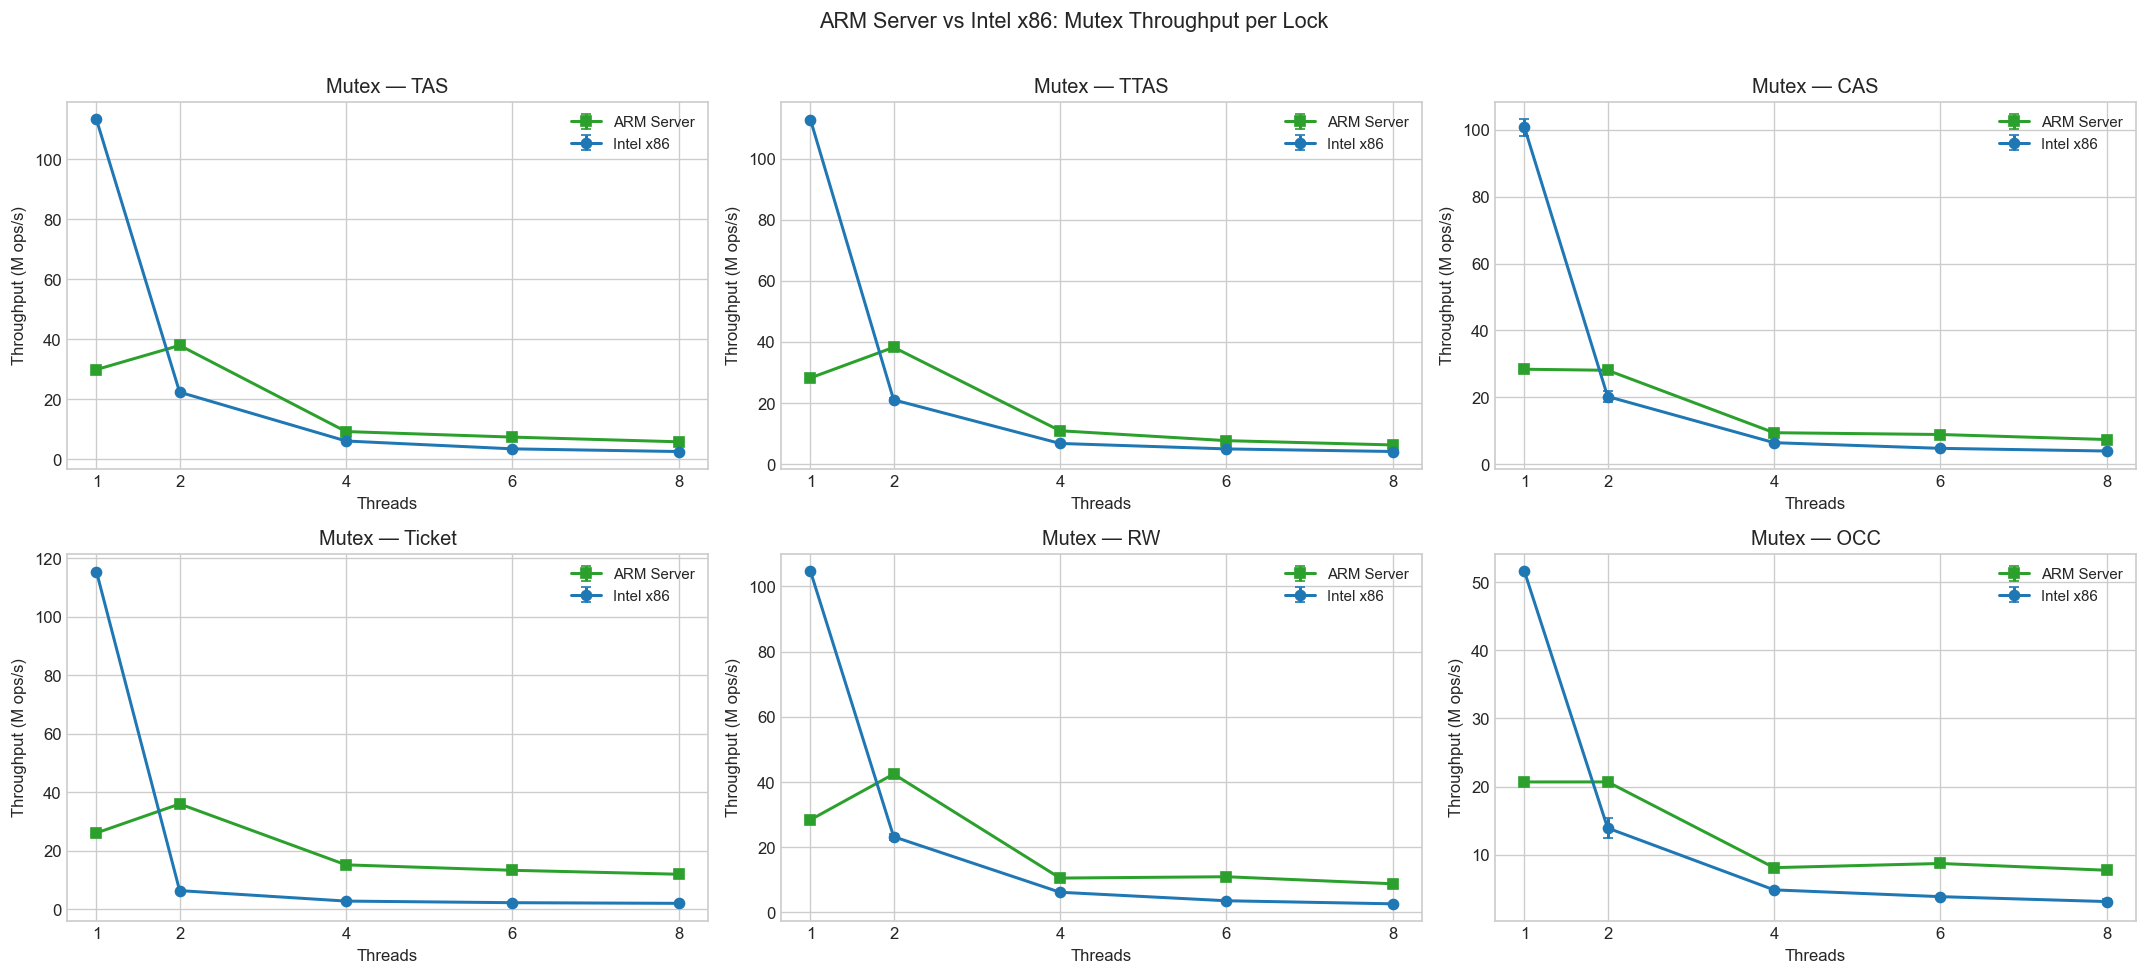

In [53]:
mutex = all_df[
    (all_df['workload'] == 'mutex') &
    (all_df['cs_work'] == 0) &
    (all_df['threads'].isin(SHARED_THREADS))
].copy()

g_mutex = agg(mutex, ['platform', 'lock', 'threads']).sort_values(['lock', 'platform', 'threads'])

mutex_locks = [l for l in LOCK_ORDER if l in mutex['lock'].unique()]
n_locks = len(mutex_locks)
ncols = 3
nrows = (n_locks + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), sharey=False)
axes = axes.flatten()

for idx, lock in enumerate(mutex_locks):
    ax = axes[idx]
    for plat in ['arm', 'x86']:
        sub = g_mutex[(g_mutex['lock'] == lock) & (g_mutex['platform'] == plat)]
        if sub.empty:
            continue
        ax.errorbar(
            sub['threads'], sub['ops_m_mean'], yerr=sub['ops_m_std'],
            label=PLAT_LABELS[plat], color=PLAT_COLORS[plat],
            marker=PLAT_MARKER[plat], linewidth=1.8, capsize=3,
        )
    ax.set_title(f'Mutex — {LOCK_LABELS[lock]}')
    ax.set_xlabel('Threads')
    ax.set_ylabel('Throughput (M ops/s)')
    ax.set_xticks(SHARED_THREADS)
    ax.legend(fontsize=9)

for ax in axes[n_locks:]:
    ax.set_visible(False)

fig.suptitle('ARM Server vs Intel x86: Mutex Throughput per Lock', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 2. Mutex Workload — Throughput Ratio (x86 / ARM)

x86 / ARM throughput ratio (>1 means x86 is faster):


,CAS,OCC,RW,TAS,Ticket,TTAS
threads,,,,,,
1,3.544,2.496,3.684,3.781,4.430,3.997
2,0.721,0.672,0.547,0.590,0.176,0.550
4,0.685,0.596,0.587,0.662,0.181,0.619
6,0.536,0.439,0.327,0.475,0.166,0.647
8,0.536,0.402,0.301,0.449,0.166,0.657


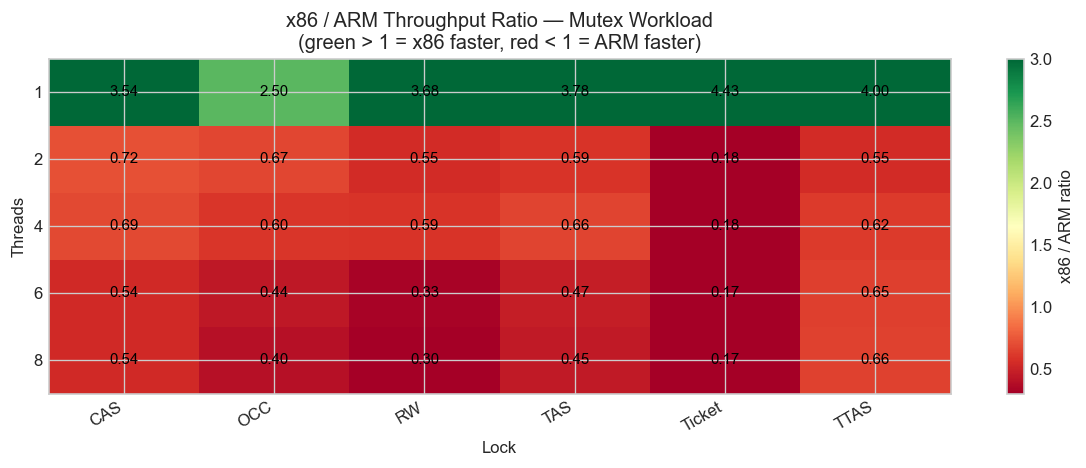

In [54]:
pivot = (
    g_mutex
      .pivot_table(index=['lock', 'threads'], columns='platform', values='ops_m_mean')
      .reset_index()
)
pivot['x86_over_arm'] = (pivot['x86'] / pivot['arm']).round(3)
pivot['arm_over_x86'] = (pivot['arm'] / pivot['x86']).round(3)

ratio_table = pivot.pivot(index='threads', columns='lock', values='x86_over_arm')
ratio_table.columns = [LOCK_LABELS.get(c, c) for c in ratio_table.columns]
print('x86 / ARM throughput ratio (>1 means x86 is faster):')
display(ratio_table.round(3))

# Heatmap
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(ratio_table.values.astype(float), aspect='auto', cmap='RdYlGn',
               vmin=0.3, vmax=3.0)
plt.colorbar(im, ax=ax, label='x86 / ARM ratio')

ax.set_xticks(range(len(ratio_table.columns)))
ax.set_xticklabels(ratio_table.columns, rotation=30, ha='right')
ax.set_yticks(range(len(ratio_table.index)))
ax.set_yticklabels(ratio_table.index)
ax.set_xlabel('Lock')
ax.set_ylabel('Threads')
ax.set_title('x86 / ARM Throughput Ratio — Mutex Workload\n(green > 1 = x86 faster, red < 1 = ARM faster)')

for i in range(len(ratio_table.index)):
    for j in range(len(ratio_table.columns)):
        v = ratio_table.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                    color='black')

fig.tight_layout()
plt.show()

## 3. Mutex Workload — Fairness Comparison

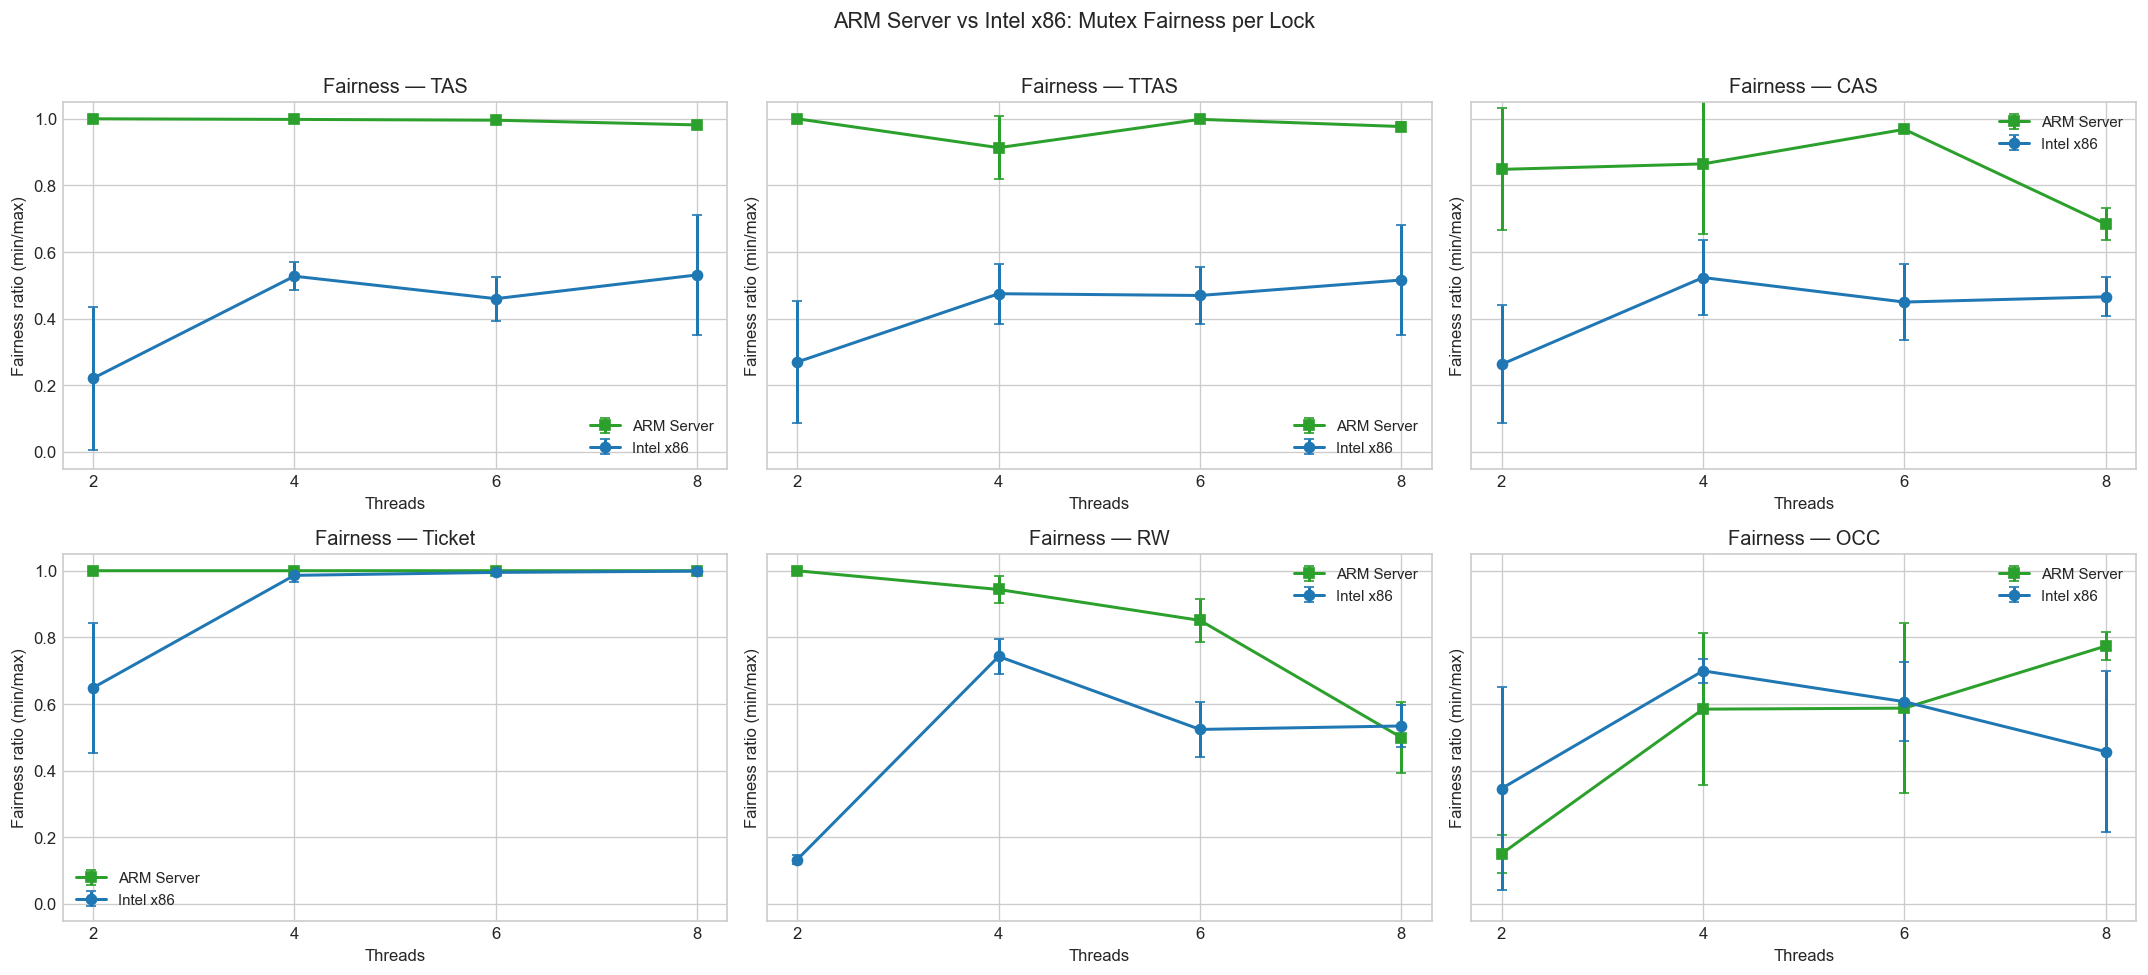

In [55]:
g_fair = g_mutex[g_mutex['threads'] > 1]

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), sharey=True)
axes = axes.flatten()

for idx, lock in enumerate(mutex_locks):
    ax = axes[idx]
    for plat in ['arm', 'x86']:
        sub = g_fair[(g_fair['lock'] == lock) & (g_fair['platform'] == plat)]
        if sub.empty:
            continue
        ax.errorbar(
            sub['threads'], sub['fair_mean'], yerr=sub['fair_std'],
            label=PLAT_LABELS[plat], color=PLAT_COLORS[plat],
            marker=PLAT_MARKER[plat], linewidth=1.8, capsize=3,
        )
    ax.set_title(f'Fairness — {LOCK_LABELS[lock]}')
    ax.set_xlabel('Threads')
    ax.set_ylabel('Fairness ratio (min/max)')
    ax.set_xticks([t for t in SHARED_THREADS if t > 1])
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=9)

for ax in axes[n_locks:]:
    ax.set_visible(False)

fig.suptitle('ARM Server vs Intel x86: Mutex Fairness per Lock', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 4. RW Workload — OCC vs RW lock, 0 / 50 / 100 % reads

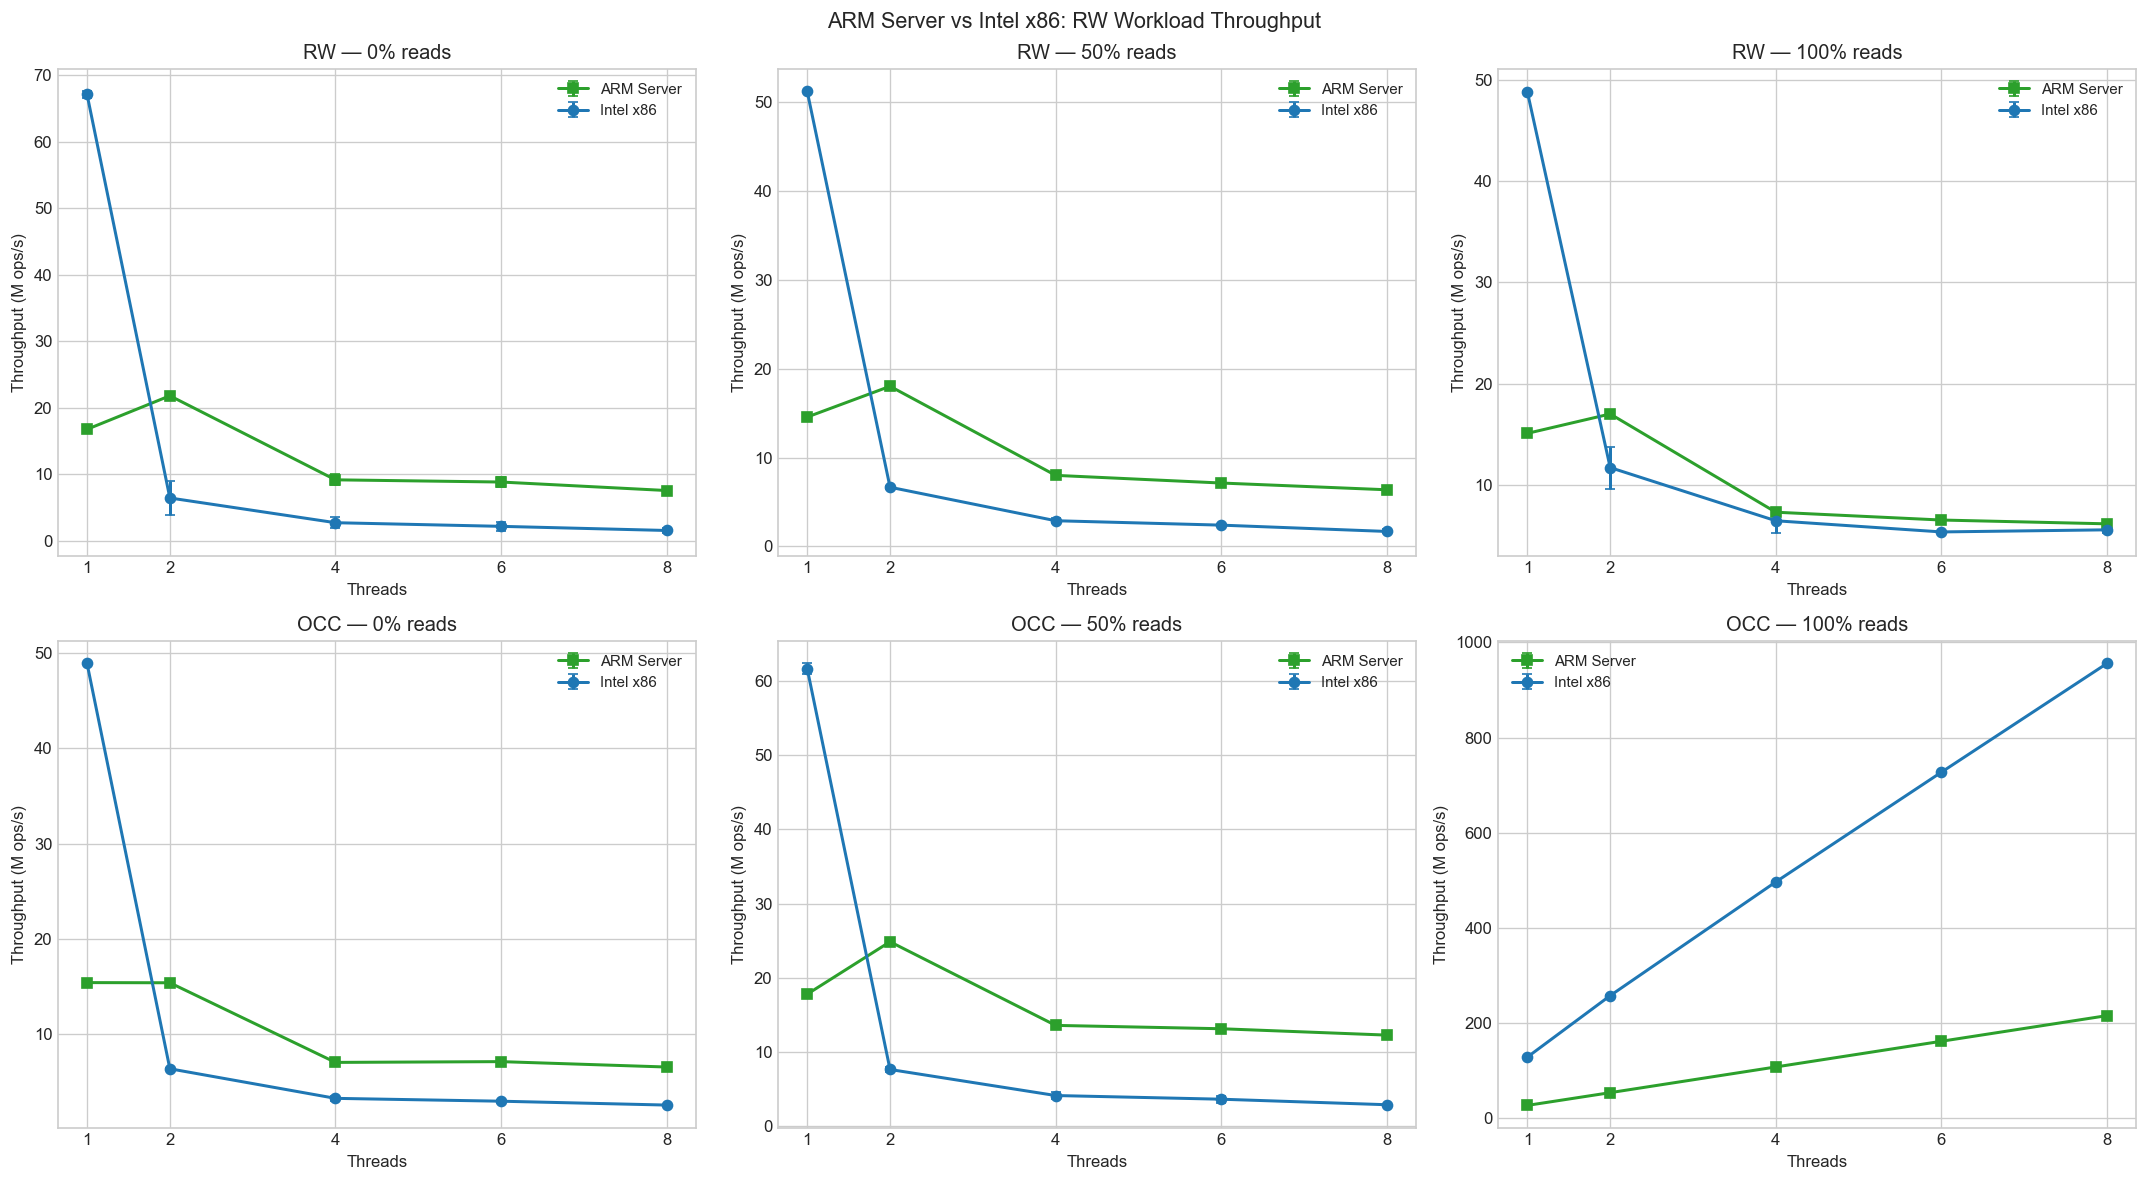


OCC / RW throughput ratio at 100% reads:
  ARM Server


lock,occ,rw,occ_over_rw
threads,,,
1,27.234,15.075,1.807
2,53.978,16.991,3.177
4,107.961,7.277,14.835
6,161.929,6.504,24.896
8,215.781,6.129,35.209


  Intel x86


lock,occ,rw,occ_over_rw
threads,,,
1,128.738,48.827,2.637
2,257.778,11.690,22.052
4,496.662,6.432,77.214
6,727.124,5.327,136.486
8,955.657,5.536,172.619


In [56]:
rw_df = all_df[
    (all_df['workload'] == 'rw') &
    (all_df['lock'].isin(['rw', 'occ'])) &
    (all_df['threads'].isin(SHARED_THREADS))
].copy()

g_rw = agg(rw_df, ['platform', 'lock', 'read_pct', 'threads'])

READ_PCTS = [0, 50, 100]
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=False)

for col, read_pct in enumerate(READ_PCTS):
    for row, lock in enumerate(['rw', 'occ']):
        ax = axes[row, col]
        for plat in ['arm', 'x86']:
            sub = g_rw[
                (g_rw['platform'] == plat) &
                (g_rw['lock'] == lock) &
                (g_rw['read_pct'] == read_pct)
            ]
            if sub.empty:
                continue
            ax.errorbar(
                sub['threads'], sub['ops_m_mean'], yerr=sub['ops_m_std'],
                label=PLAT_LABELS[plat], color=PLAT_COLORS[plat],
                marker=PLAT_MARKER[plat], linewidth=1.8, capsize=3,
            )
        ax.set_title(f'{LOCK_LABELS[lock]} — {read_pct}% reads')
        ax.set_xlabel('Threads')
        ax.set_ylabel('Throughput (M ops/s)')
        ax.set_xticks(SHARED_THREADS)
        ax.legend(fontsize=9)

fig.suptitle('ARM Server vs Intel x86: RW Workload Throughput', fontsize=13)
fig.tight_layout()
plt.show()

# OCC / RW ratio per platform at 100% reads
print('\nOCC / RW throughput ratio at 100% reads:')
for plat in ['arm', 'x86']:
    sub100 = g_rw[(g_rw['read_pct'] == 100) & (g_rw['platform'] == plat)]
    ratio = (
        sub100.pivot(index='threads', columns='lock', values='ops_m_mean')
              .assign(occ_over_rw=lambda d: d['occ'] / d['rw'])
              .round(3)
    )
    print(f'  {PLAT_LABELS[plat]}')
    display(ratio)

## 5. RCU Workload — 0 / 50 / 100 % reads

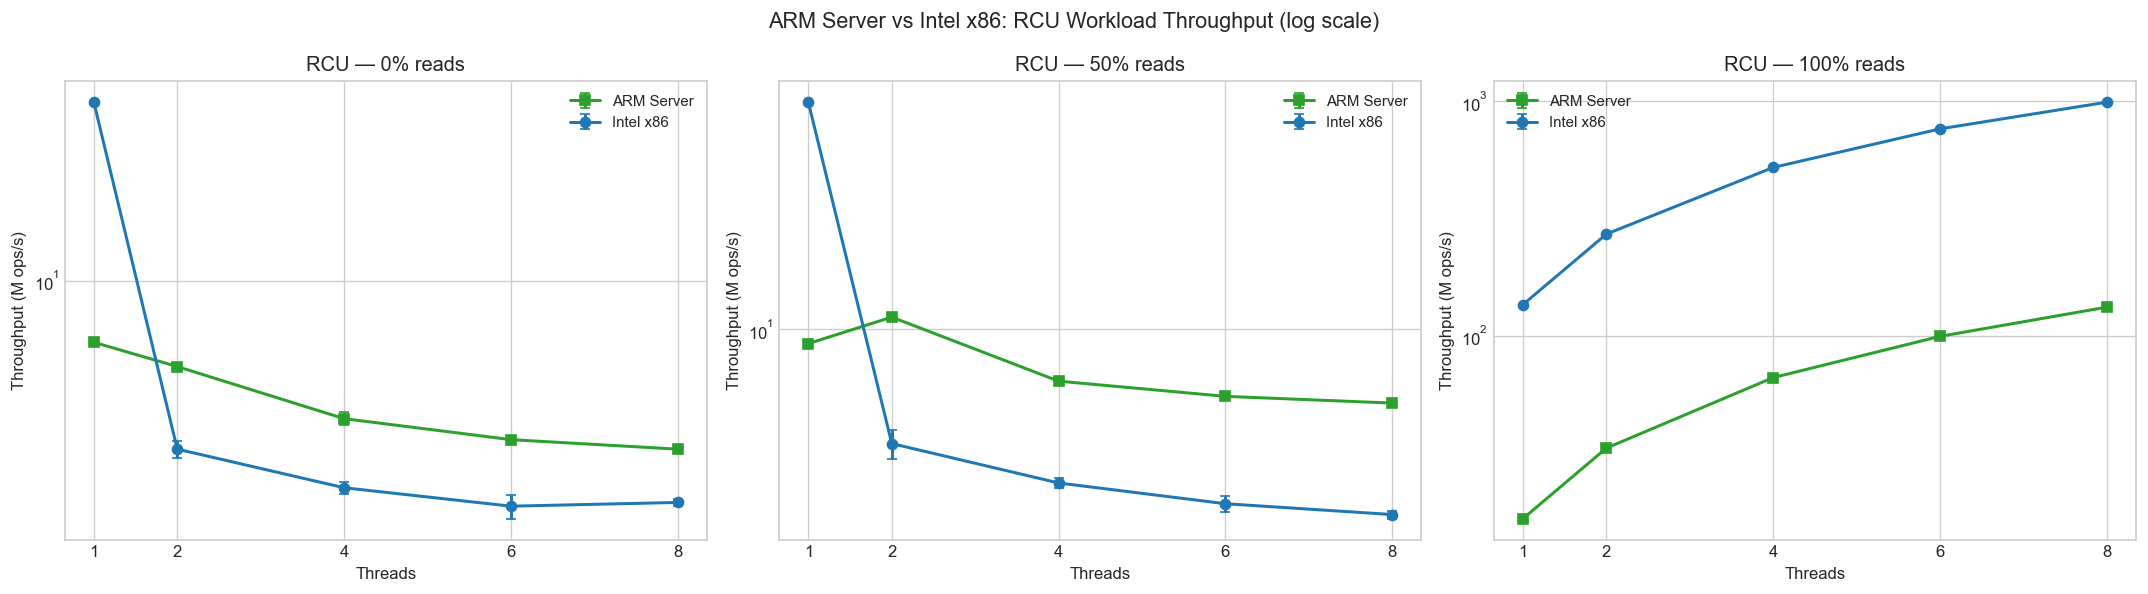


RCU throughput ratio x86/ARM by read_pct and threads:


platform              arm      x86  x86_over_arm
read_pct threads                                
0        1          6.878   29.482         4.286
         2          5.938    3.600         0.606
         4          4.330    2.849         0.658
         6          3.813    2.548         0.668
         8          3.600    2.606         0.724
50       1          9.157   40.029         4.372
         2         10.765    4.968         0.461
         4          7.277    3.904         0.537
         6          6.631    3.439         0.519
         8          6.364    3.219         0.506
100      1         16.531  135.545         8.199
         2         33.069  270.916         8.193
         4         66.123  521.551         7.888
         6         99.168  762.064         7.685
         8        132.162  990.924         7.498

In [57]:
rcu_df = all_df[
    (all_df['workload'] == 'rcu') &
    (all_df['lock'] == 'rcu') &
    (all_df['threads'].isin(SHARED_THREADS))
].copy()

g_rcu = agg(rcu_df, ['platform', 'read_pct', 'threads'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, read_pct in zip(axes, READ_PCTS):
    for plat in ['arm', 'x86']:
        sub = g_rcu[(g_rcu['platform'] == plat) & (g_rcu['read_pct'] == read_pct)]
        if sub.empty:
            continue
        ax.errorbar(
            sub['threads'], sub['ops_m_mean'], yerr=sub['ops_m_std'],
            label=PLAT_LABELS[plat], color=PLAT_COLORS[plat],
            marker=PLAT_MARKER[plat], linewidth=1.8, capsize=3,
        )
    ax.set_title(f'RCU — {read_pct}% reads')
    ax.set_xlabel('Threads')
    ax.set_ylabel('Throughput (M ops/s)')
    ax.set_xticks(SHARED_THREADS)
    ax.set_yscale('log')
    ax.legend(fontsize=9)

fig.suptitle('ARM Server vs Intel x86: RCU Workload Throughput (log scale)', fontsize=13)
fig.tight_layout()
plt.show()

# Cross-platform ratio for RCU
print('\nRCU throughput ratio x86/ARM by read_pct and threads:')
rcu_ratio = (
    g_rcu.pivot_table(index=['read_pct', 'threads'], columns='platform', values='ops_m_mean')
         .assign(x86_over_arm=lambda d: d['x86'] / d['arm'])
         .round(3)
)
display(rcu_ratio)

## 6. Latency (ns/op) — Single-threaded baseline comparison

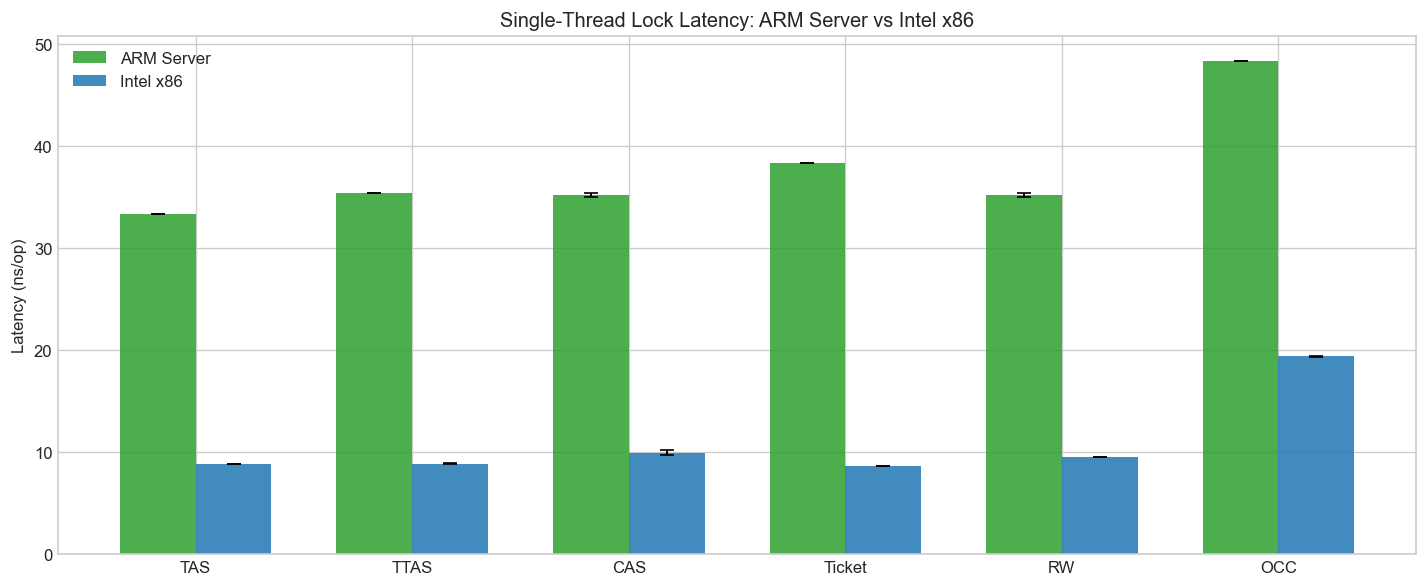

Single-thread latency (ns/op):


,arm,x86,x86_over_arm
TAS,33.364,8.824,0.264
TTAS,35.451,8.869,0.250
CAS,35.201,9.938,0.282
Ticket,38.369,8.661,0.226
RW,35.202,9.556,0.271
OCC,48.382,19.384,0.401


In [58]:
lat1 = all_df[
    (all_df['workload'] == 'mutex') &
    (all_df['cs_work'] == 0) &
    (all_df['threads'] == 1)
].copy()

g_lat1 = (
    lat1.groupby(['platform', 'lock'])
        .agg(ns_mean=('ns_op', 'mean'), ns_std=('ns_op', 'std'))
        .reset_index()
)

locks_present = [l for l in LOCK_ORDER if l in g_lat1['lock'].unique()]
x = np.arange(len(locks_present))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
for i, plat in enumerate(['arm', 'x86']):
    sub = g_lat1[g_lat1['platform'] == plat].set_index('lock').reindex(locks_present)
    ax.bar(x + i * width, sub['ns_mean'], width, yerr=sub['ns_std'],
           label=PLAT_LABELS[plat], color=PLAT_COLORS[plat],
           alpha=0.85, capsize=4, error_kw={'elinewidth': 1.2})

ax.set_xticks(x + width / 2)
ax.set_xticklabels([LOCK_LABELS[l] for l in locks_present])
ax.set_ylabel('Latency (ns/op)')
ax.set_title('Single-Thread Lock Latency: ARM Server vs Intel x86')
ax.legend()
fig.tight_layout()
plt.show()

# Table
lat_table = (
    g_lat1.pivot(index='lock', columns='platform', values='ns_mean')
          .reindex(locks_present)
          .assign(x86_over_arm=lambda d: d['x86'] / d['arm'])
          .round(3)
)
lat_table.index = [LOCK_LABELS.get(i, i) for i in lat_table.index]
lat_table.columns.name = None
print('Single-thread latency (ns/op):')
display(lat_table)

## 7. Scaling behaviour — throughput vs threads (all locks, both platforms)

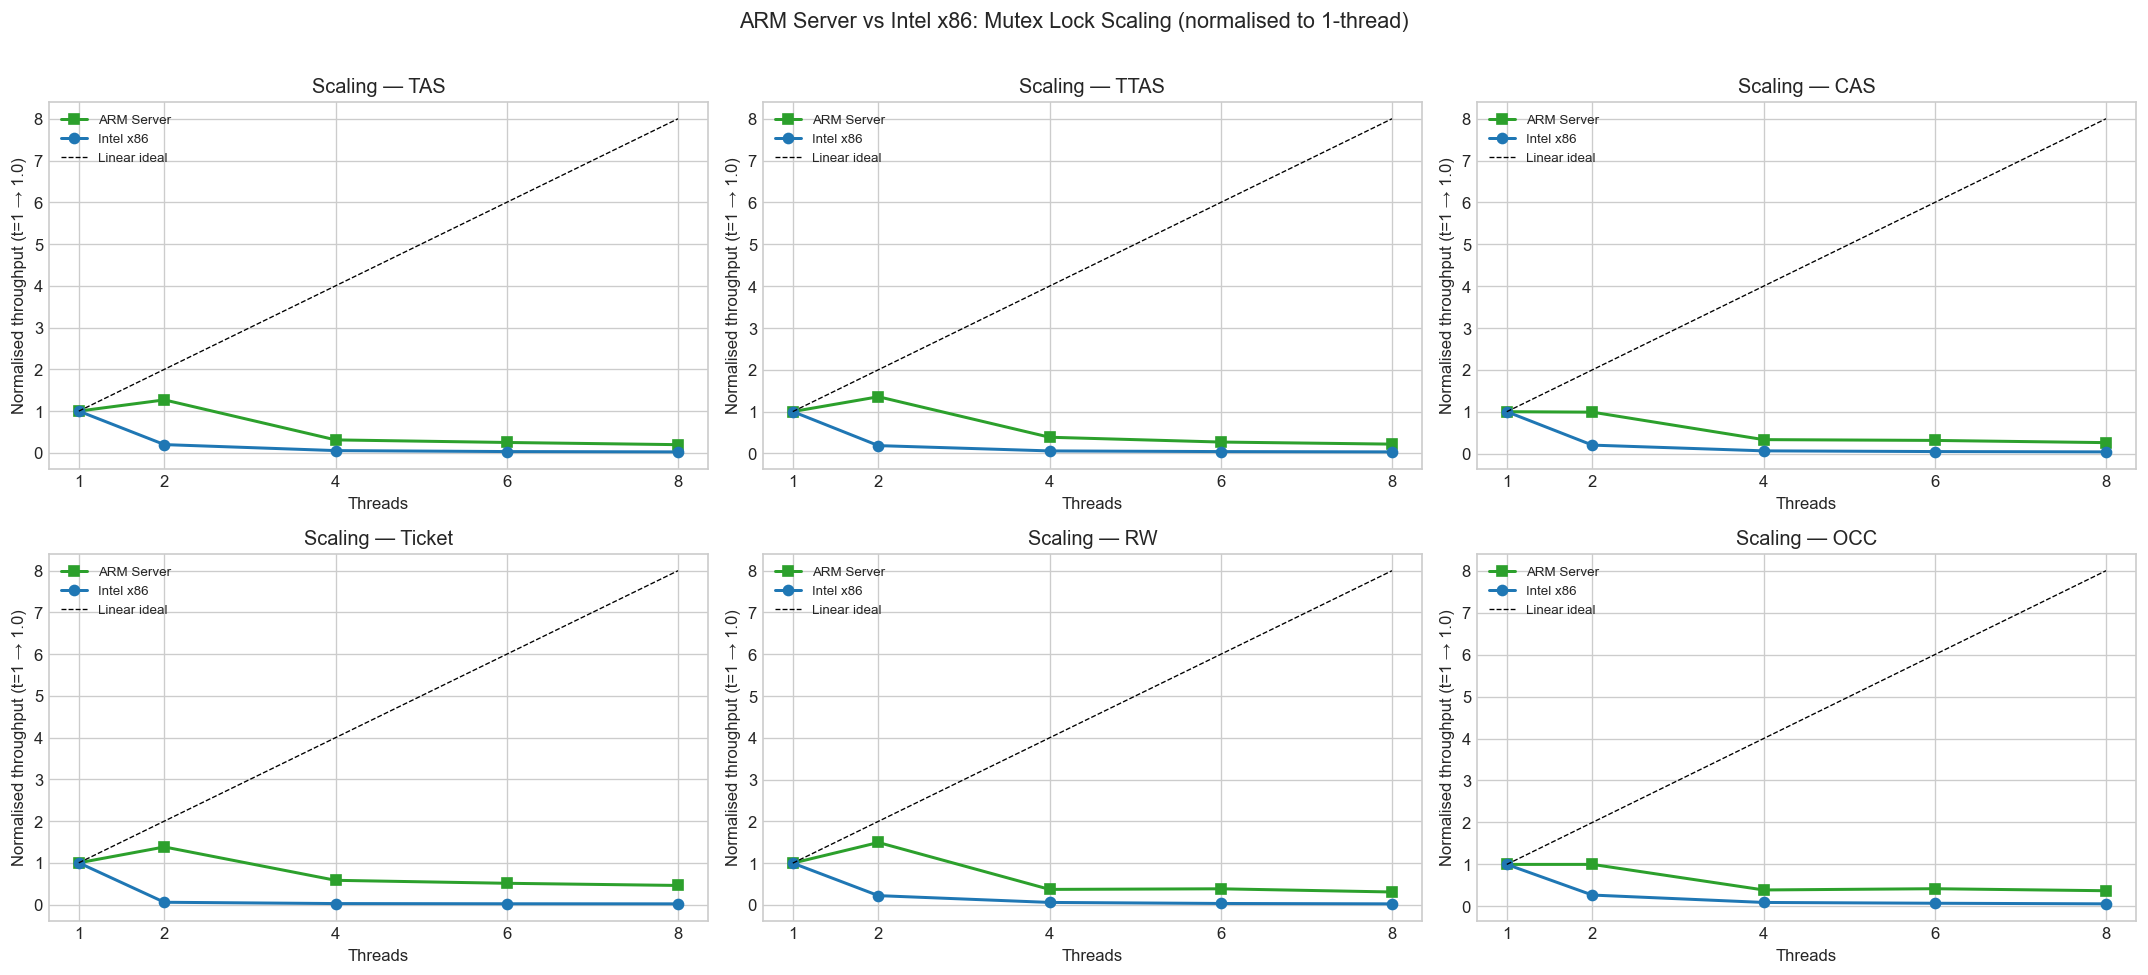

In [59]:
# Normalise throughput to each lock's single-thread value to compare scaling curves
g_scale = g_mutex.copy()
t1 = g_scale[g_scale['threads'] == 1][['platform', 'lock', 'ops_m_mean']].rename(
        columns={'ops_m_mean': 'ops_m_t1'})
g_scale = g_scale.merge(t1, on=['platform', 'lock'])
g_scale['scaled'] = g_scale['ops_m_mean'] / g_scale['ops_m_t1']

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), sharey=False)
axes = axes.flatten()

for idx, lock in enumerate(mutex_locks):
    ax = axes[idx]
    for plat in ['arm', 'x86']:
        sub = g_scale[(g_scale['lock'] == lock) & (g_scale['platform'] == plat)]
        if sub.empty:
            continue
        ax.plot(sub['threads'], sub['scaled'],
                label=PLAT_LABELS[plat], color=PLAT_COLORS[plat],
                marker=PLAT_MARKER[plat], linewidth=1.8)
    # ideal linear scaling reference
    ax.plot(SHARED_THREADS, SHARED_THREADS, 'k--', linewidth=0.8, label='Linear ideal')
    ax.set_title(f'Scaling — {LOCK_LABELS[lock]}')
    ax.set_xlabel('Threads')
    ax.set_ylabel('Normalised throughput (t=1 → 1.0)')
    ax.set_xticks(SHARED_THREADS)
    ax.legend(fontsize=8)

for ax in axes[n_locks:]:
    ax.set_visible(False)

fig.suptitle('ARM Server vs Intel x86: Mutex Lock Scaling (normalised to 1-thread)', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 8. x86-only: High-thread scaling (16 and 32 threads)

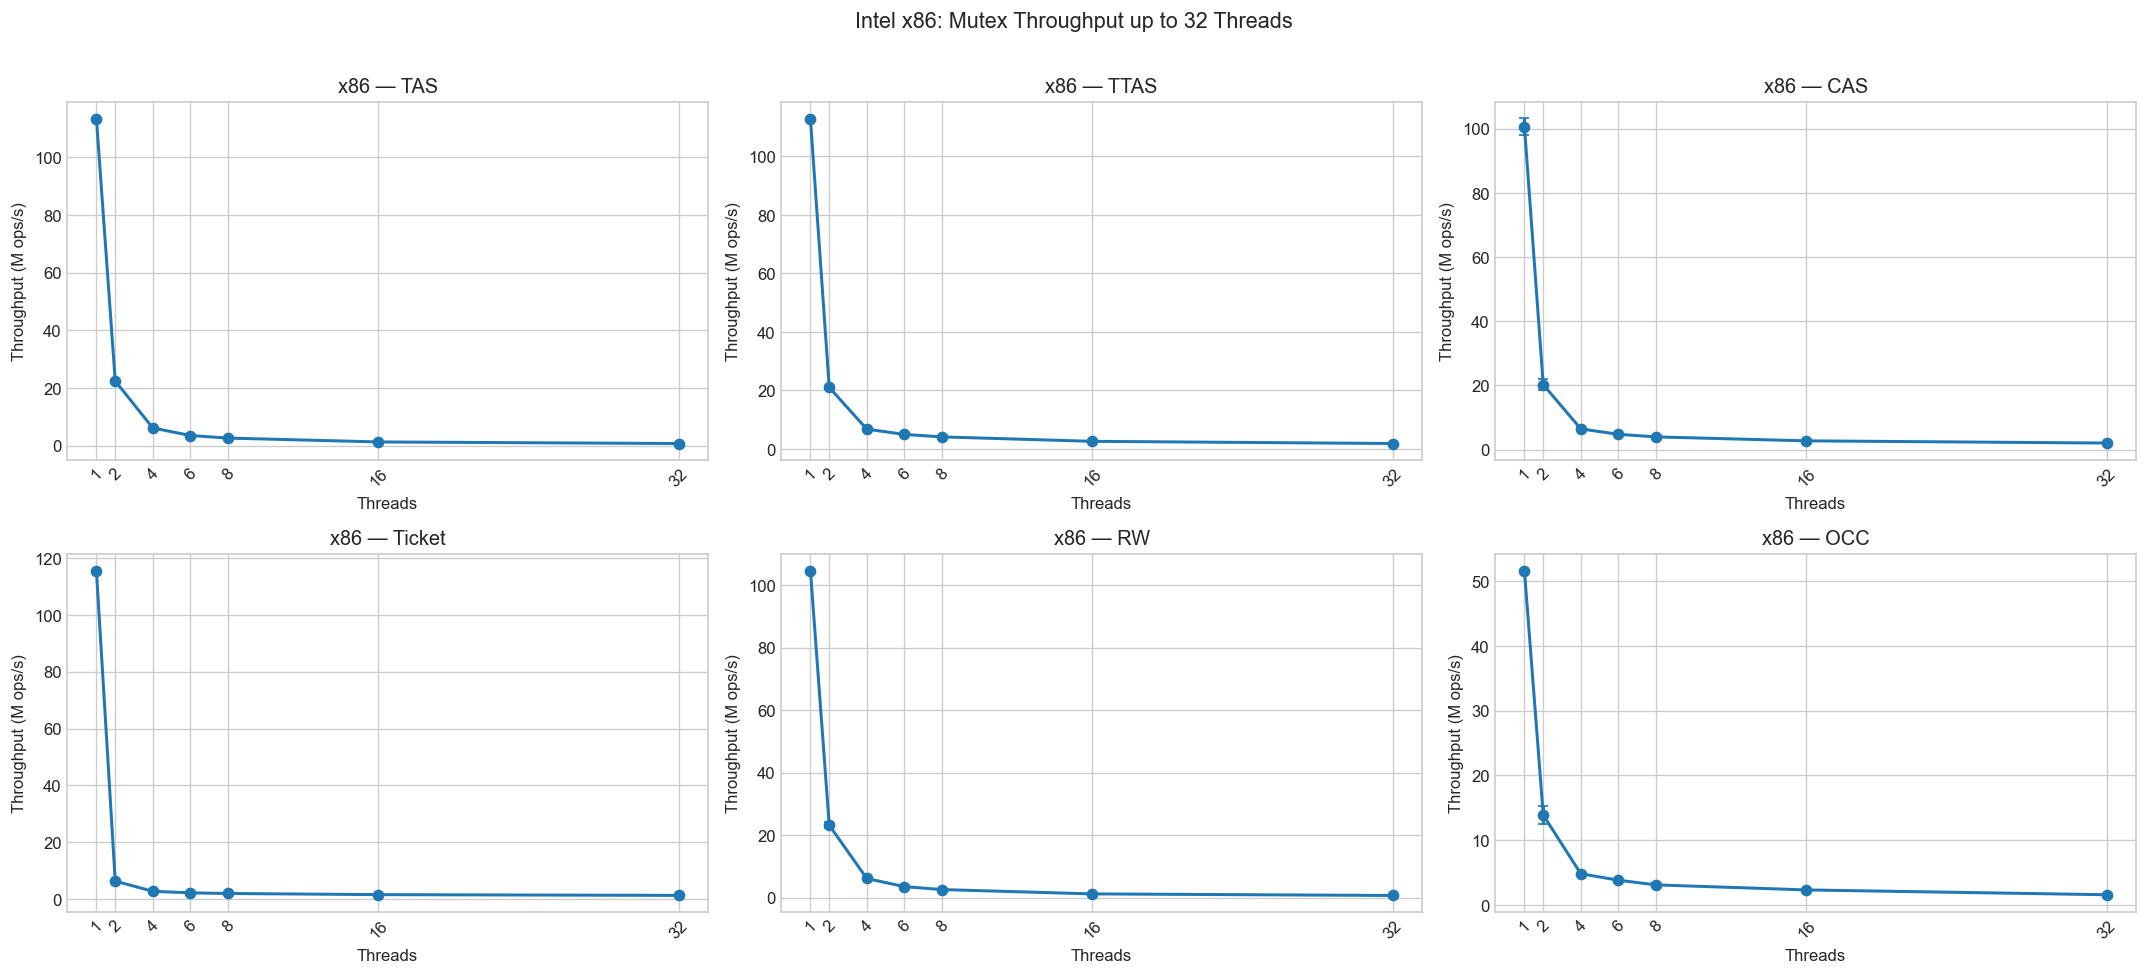

In [60]:
x86_mutex = x86[
    (x86['workload'] == 'mutex') &
    (x86['cs_work'] == 0)
].copy()

g_x86_mutex = agg(x86_mutex, ['lock', 'threads']).sort_values(['lock', 'threads'])

ALL_X86_THREADS = sorted(x86_mutex['threads'].dropna().astype(int).unique())

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), sharey=False)
axes = axes.flatten()

for idx, lock in enumerate(mutex_locks):
    ax = axes[idx]
    sub = g_x86_mutex[g_x86_mutex['lock'] == lock]
    if sub.empty:
        continue
    ax.errorbar(
        sub['threads'], sub['ops_m_mean'], yerr=sub['ops_m_std'],
        color=PLAT_COLORS['x86'], marker='o', linewidth=1.8, capsize=3,
    )
    ax.set_title(f'x86 — {LOCK_LABELS[lock]}')
    ax.set_xlabel('Threads')
    ax.set_ylabel('Throughput (M ops/s)')
    ax.set_xticks(ALL_X86_THREADS)
    ax.tick_params(axis='x', labelrotation=45)

for ax in axes[n_locks:]:
    ax.set_visible(False)

fig.suptitle('Intel x86: Mutex Throughput up to 32 Threads', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 9. Per-Platform Lock Ranking — Which lock wins at each thread count?

For each platform and thread count, rank locks by mean throughput.  


Intel x86 — Lock ranking by throughput (1 = fastest):


lock,CAS,OCC,RW,TAS,Ticket,TTAS
threads,,,,,,
1,5,6,4,2,1,3
2,4,5,1,2,6,3
4,2,5,3,4,6,1
6,2,3,4,5,6,1
8,2,3,5,4,6,1



ARM Server — Lock ranking by throughput (1 = fastest):


lock,CAS,OCC,RW,TAS,Ticket,TTAS
threads,,,,,,
1,2,6,3,1,5,4
2,5,6,1,3,4,2
4,4,6,3,5,1,2
6,3,4,2,6,1,5
8,4,3,2,6,1,5


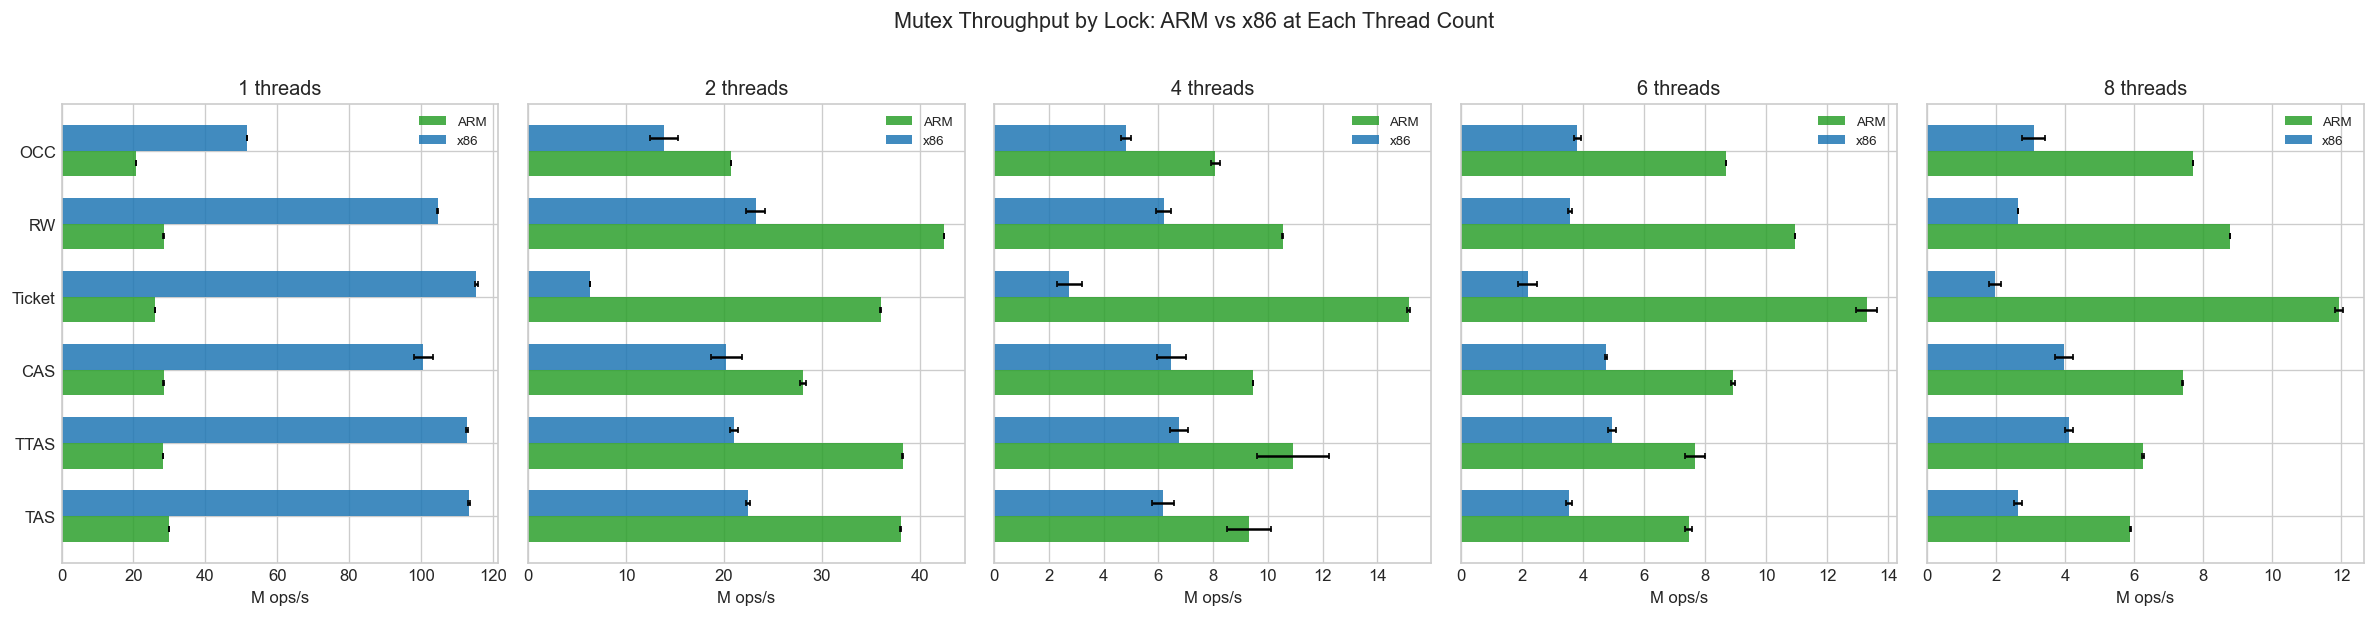

In [61]:
# Per-platform lock ranking by throughput (mutex workload)
for plat in ['x86', 'arm']:
    sub = g_mutex[g_mutex['platform'] == plat].copy()
    rank = (
        sub.pivot(index='threads', columns='lock', values='ops_m_mean')
           .rename(columns=LOCK_LABELS)
    )
    # Rank: 1 = fastest
    rank_order = rank.rank(axis=1, ascending=False).astype(int)
    print(f'\n{PLAT_LABELS[plat]} — Lock ranking by throughput (1 = fastest):')
    display(rank_order)

# Side-by-side bar chart: best lock per thread count per platform
fig, axes = plt.subplots(1, len(SHARED_THREADS), figsize=(4 * len(SHARED_THREADS), 5), sharey=True)

for ax, t in zip(axes, SHARED_THREADS):
    sub = g_mutex[g_mutex['threads'] == t].copy()
    sub['label'] = sub['lock'].map(LOCK_LABELS)
    
    arm_sub = sub[sub['platform'] == 'arm'].set_index('label').reindex([LOCK_LABELS[l] for l in mutex_locks])
    x86_sub = sub[sub['platform'] == 'x86'].set_index('label').reindex([LOCK_LABELS[l] for l in mutex_locks])
    
    x = np.arange(len(mutex_locks))
    w = 0.35
    ax.barh(x - w/2, arm_sub['ops_m_mean'], w, xerr=arm_sub['ops_m_std'],
            color=PLAT_COLORS['arm'], label='ARM', capsize=2, alpha=0.85)
    ax.barh(x + w/2, x86_sub['ops_m_mean'], w, xerr=x86_sub['ops_m_std'],
            color=PLAT_COLORS['x86'], label='x86', capsize=2, alpha=0.85)
    ax.set_yticks(x)
    ax.set_yticklabels([LOCK_LABELS[l] for l in mutex_locks])
    ax.set_xlabel('M ops/s')
    ax.set_title(f'{t} threads')
    ax.legend(fontsize=8)

fig.suptitle('Mutex Throughput by Lock: ARM vs x86 at Each Thread Count', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## 10. Coefficient of Variation (CV) — Run-to-Run Stability

CV = std / mean. 

/var/folders/bx/qxvsk6k93_g7w59yp71ff7tw0000gn/T/ipykernel_28684/3833662087.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


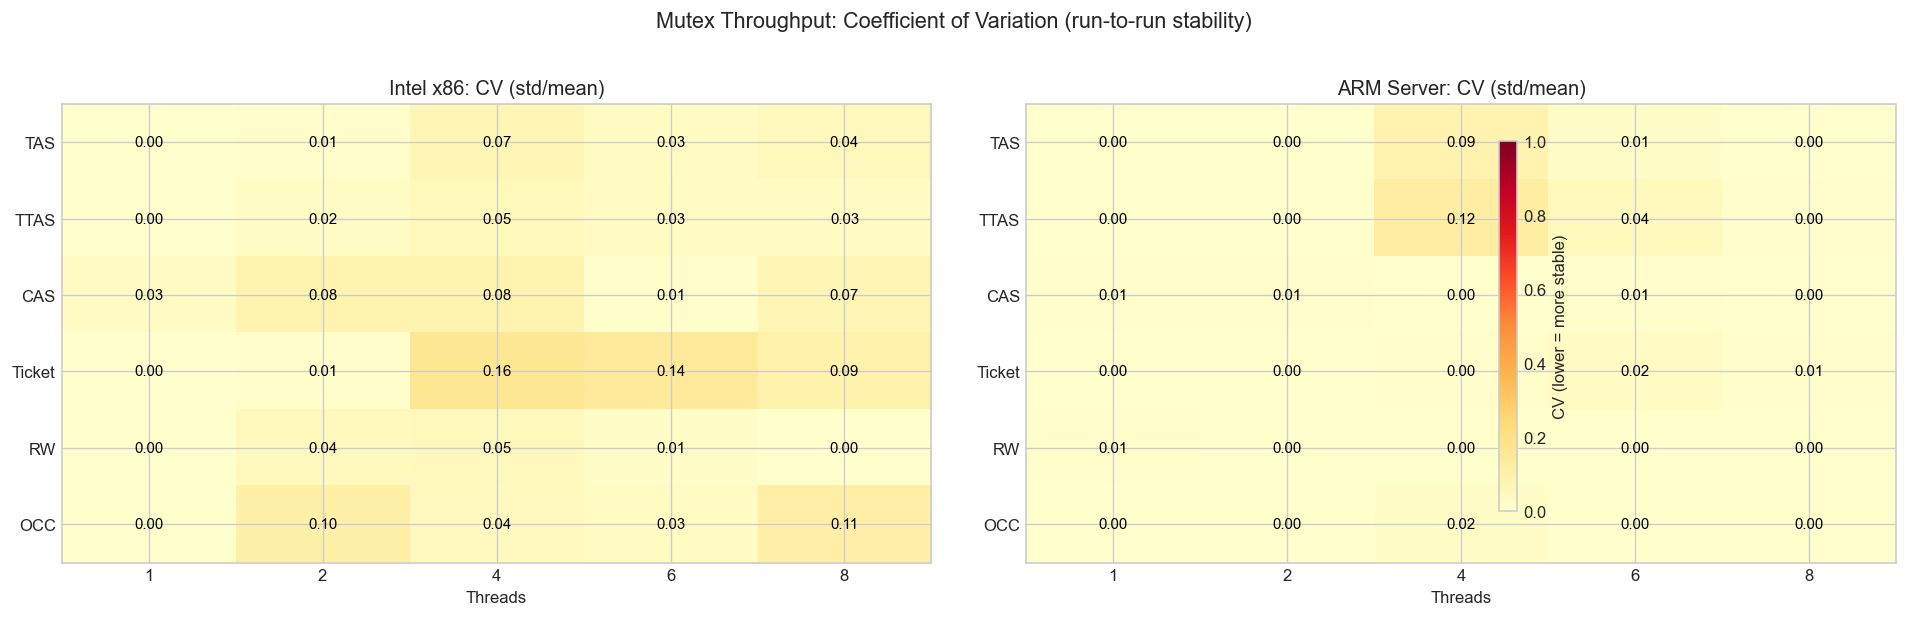

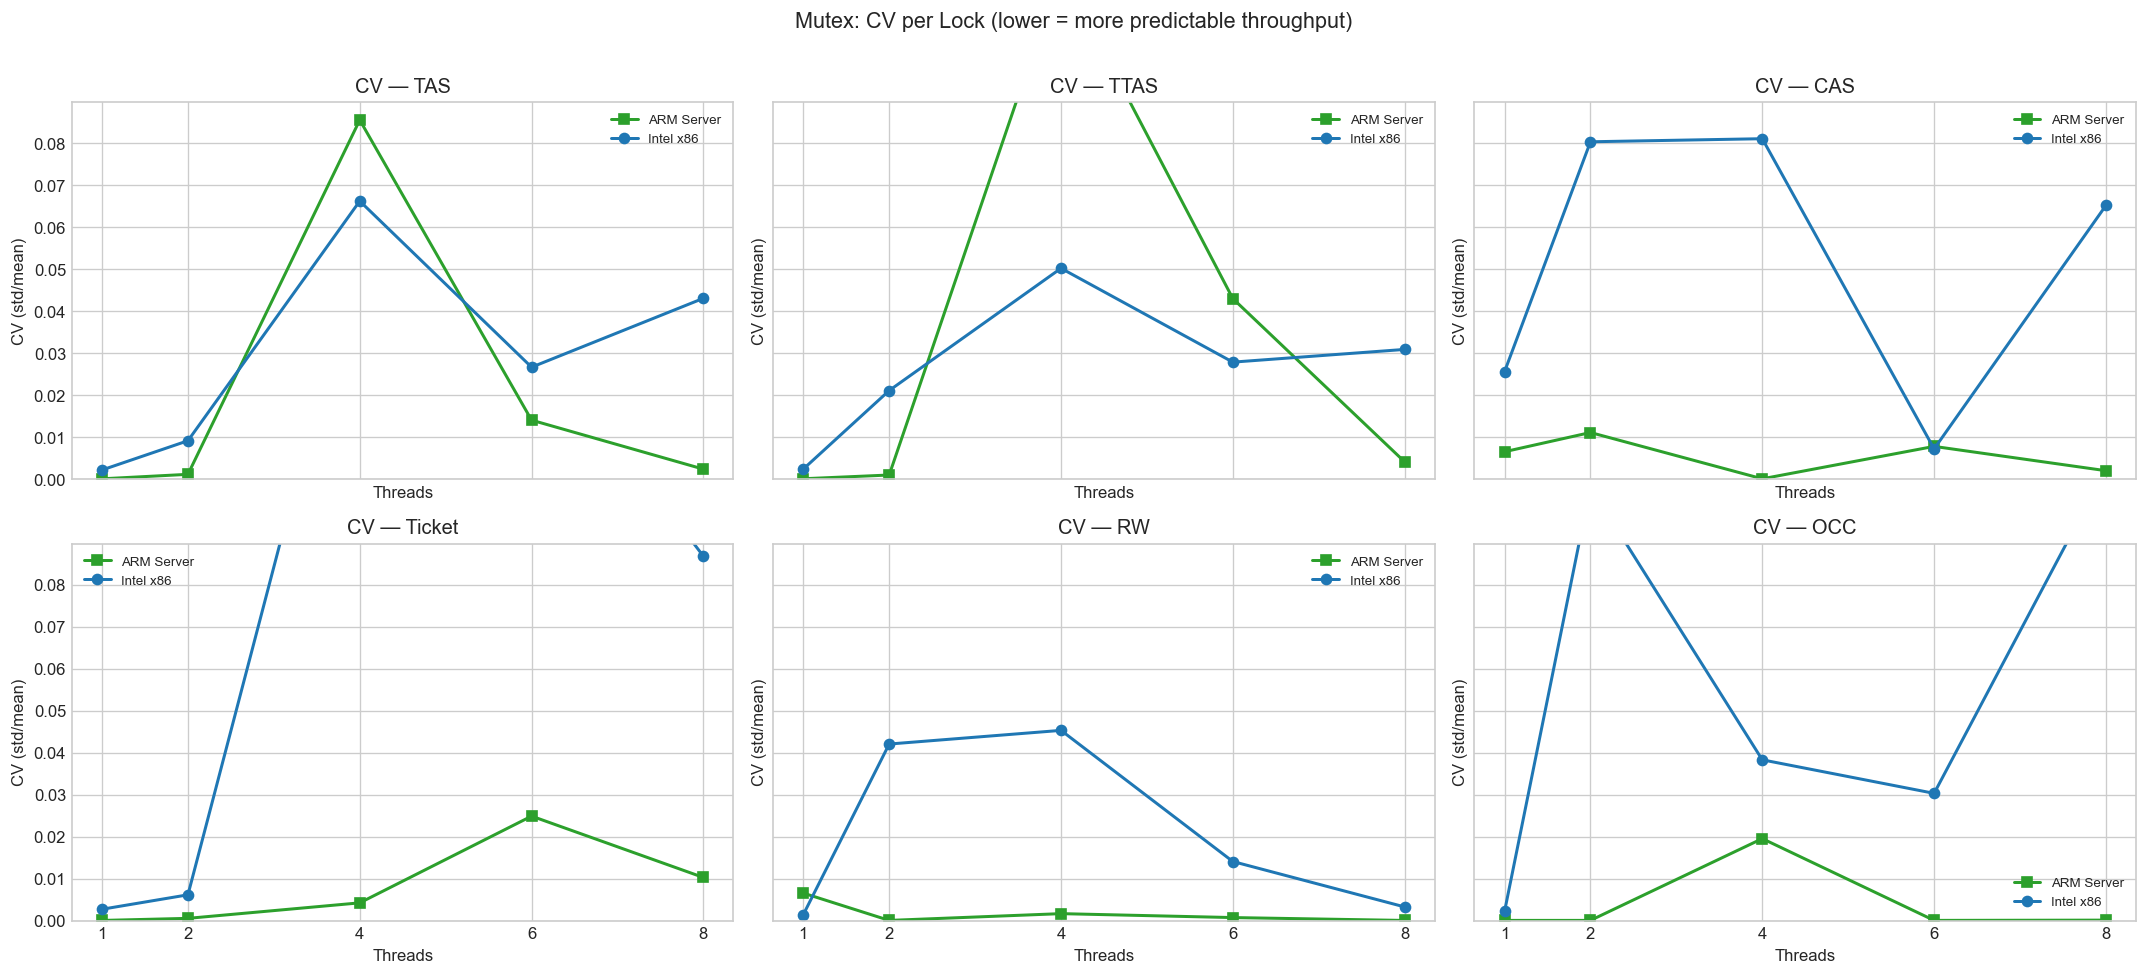

CV difference (ARM - x86), positive = ARM noisier:


,TAS,TTAS,CAS,Ticket,RW,OCC
threads,,,,,,
1,-0.002,-0.002,-0.019,-0.003,0.005,-0.002
2,-0.008,-0.020,-0.069,-0.006,-0.042,-0.103
4,0.019,0.071,-0.081,-0.158,-0.044,-0.019
6,-0.013,0.015,0.001,-0.116,-0.013,-0.030
8,-0.041,-0.027,-0.063,-0.077,-0.003,-0.107


In [62]:
# Coefficient of variation for mutex workload (throughput)
g_cv = g_mutex.copy()
g_cv['cv'] = g_cv['ops_m_std'] / g_cv['ops_m_mean']

# CV heatmap per platform
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, plat in zip(axes, ['x86', 'arm']):
    sub = g_cv[g_cv['platform'] == plat]
    heat = sub.pivot(index='lock', columns='threads', values='cv')
    heat = heat.reindex([l for l in LOCK_ORDER if l in heat.index])
    heat.index = [LOCK_LABELS.get(l, l) for l in heat.index]
    
    im = ax.imshow(heat.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1.0)
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels([int(c) for c in heat.columns])
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(heat.index)
    ax.set_xlabel('Threads')
    ax.set_title(f'{PLAT_LABELS[plat]}: CV (std/mean)')
    
    for i in range(len(heat.index)):
        for j in range(len(heat.columns)):
            v = heat.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                        color='white' if v > 0.5 else 'black')

fig.colorbar(im, ax=axes, label='CV (lower = more stable)', shrink=0.8)
fig.suptitle('Mutex Throughput: Coefficient of Variation (run-to-run stability)', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

# CV comparison: ARM vs x86 per lock
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), sharex=True, sharey=True)
axes_flat = axes.flatten()
for idx, lock in enumerate(mutex_locks):
    ax = axes_flat[idx]
    for plat in ['arm', 'x86']:
        sub = g_cv[(g_cv['lock'] == lock) & (g_cv['platform'] == plat)]
        ax.plot(sub['threads'], sub['cv'],
                label=PLAT_LABELS[plat], color=PLAT_COLORS[plat],
                marker=PLAT_MARKER[plat], linewidth=1.8)
    ax.set_title(f'CV — {LOCK_LABELS[lock]}')
    ax.set_xlabel('Threads')
    ax.set_ylabel('CV (std/mean)')
    ax.set_xticks(SHARED_THREADS)
    ax.legend(fontsize=8)
    ax.set_ylim(0, None)

for ax in axes_flat[len(mutex_locks):]:
    ax.set_visible(False)

fig.suptitle('Mutex: CV per Lock (lower = more predictable throughput)', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

# Table: CV difference (ARM - x86), positive means ARM is noisier
cv_pivot = g_cv.pivot(index=['lock', 'threads'], columns='platform', values='cv').reset_index()
cv_pivot['arm_minus_x86'] = cv_pivot['arm'] - cv_pivot['x86']
cv_table = cv_pivot.pivot(index='threads', columns='lock', values='arm_minus_x86')
cv_table = cv_table[[l for l in LOCK_ORDER if l in cv_table.columns]]
cv_table.columns = [LOCK_LABELS.get(c, c) for c in cv_table.columns]
print('CV difference (ARM - x86), positive = ARM noisier:')
display(cv_table.round(3))

## 11. Contention Penalty — How much does each lock degrade from 1T to 8T?

Contention ratio = throughput(8T) / throughput(1T).

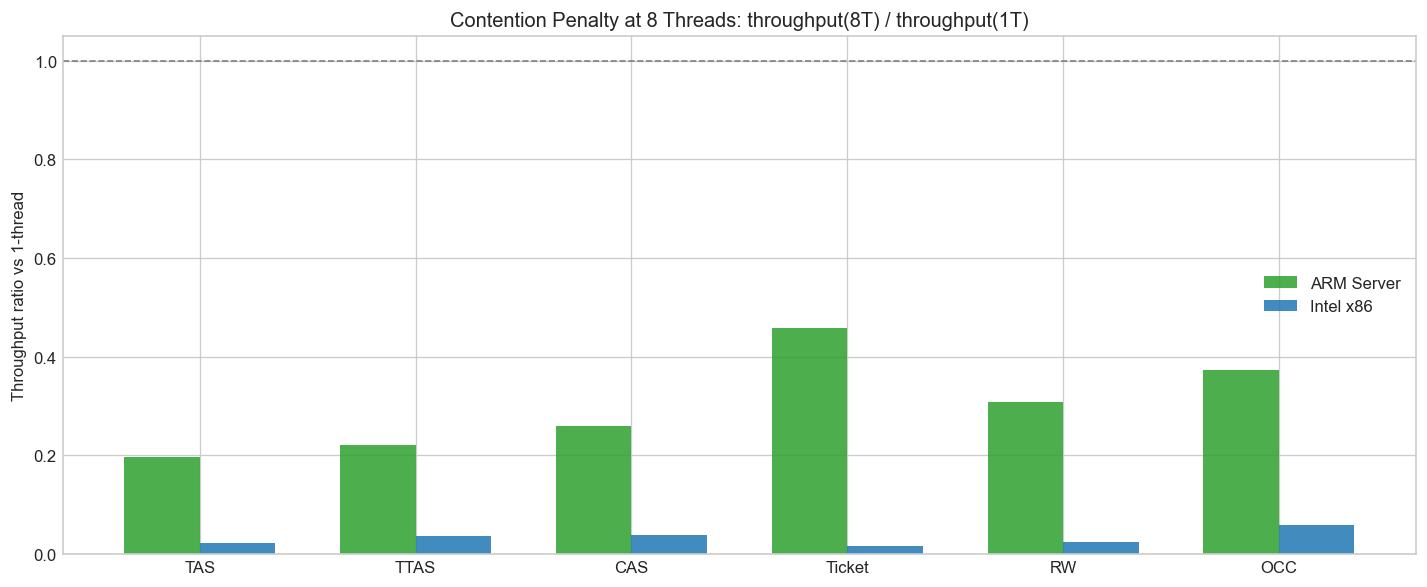

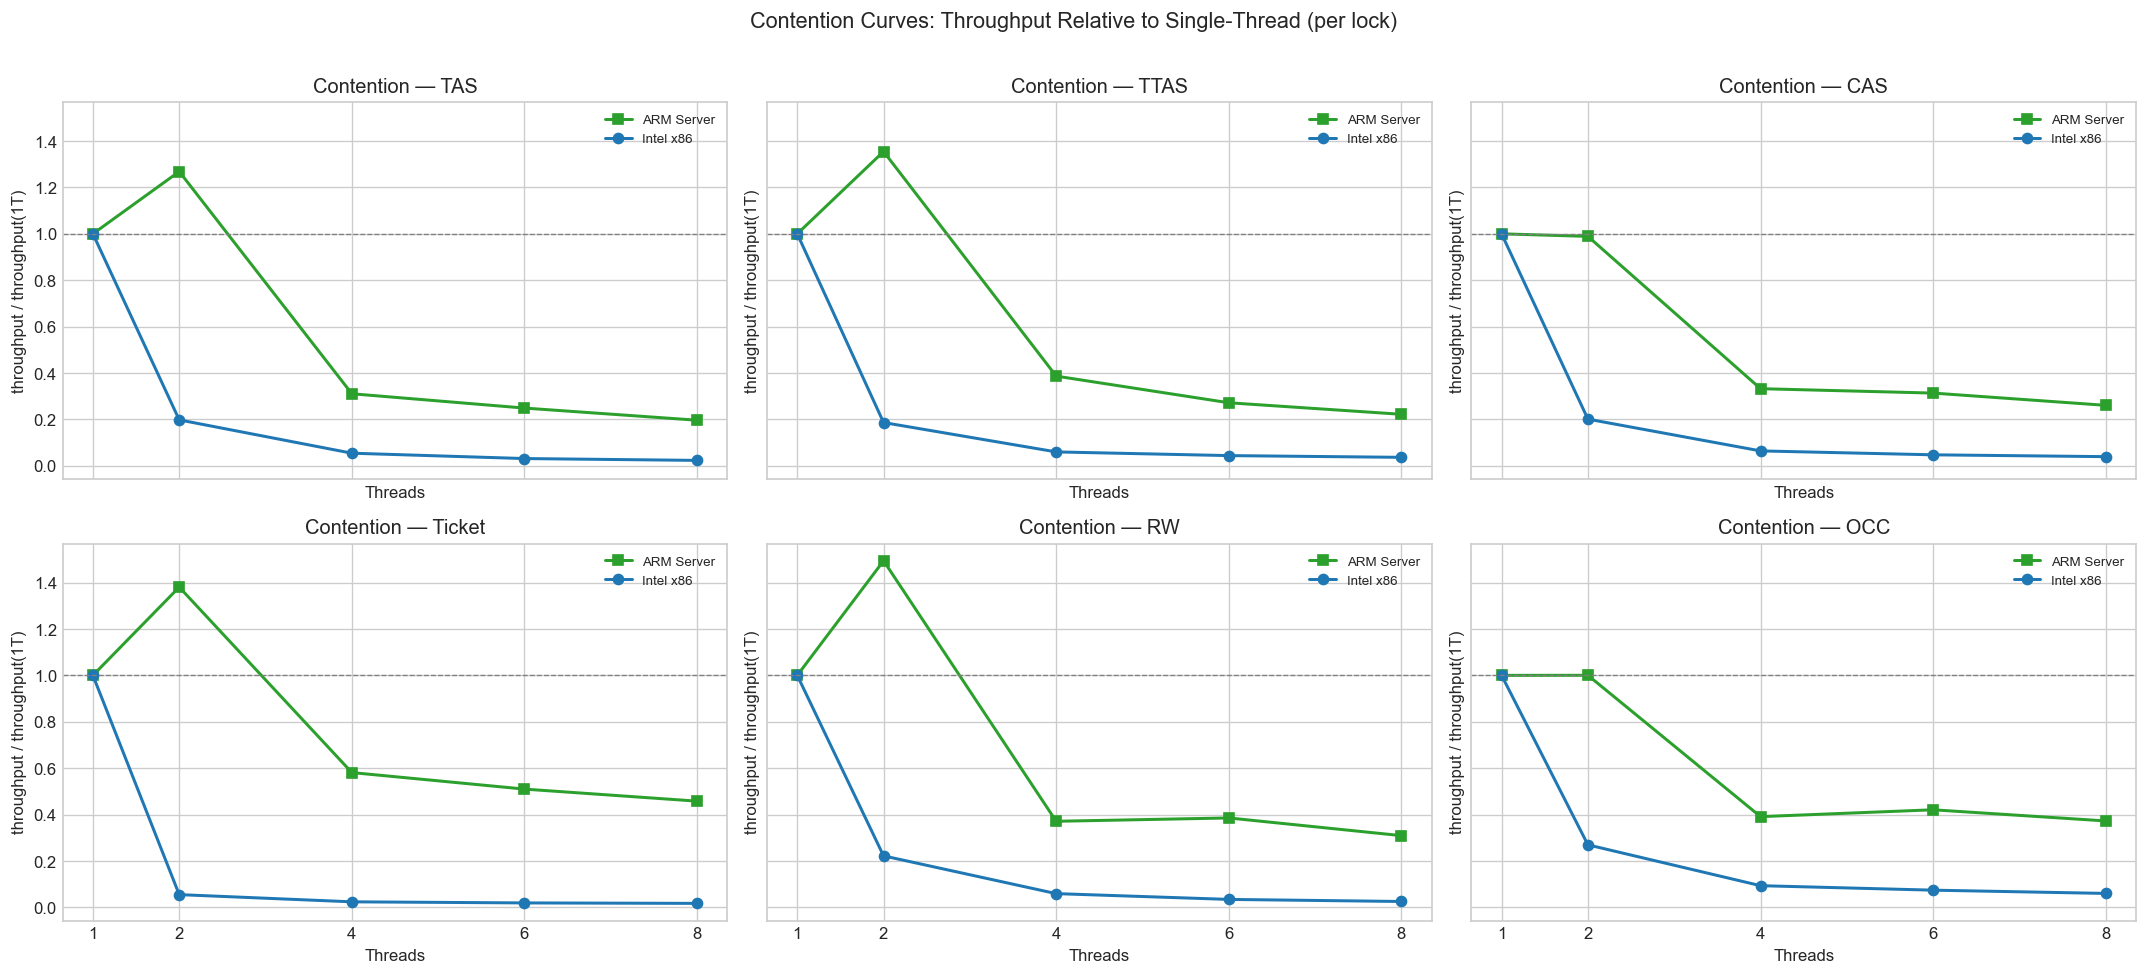

Contention ratio at 8T (>1 = scales positively, <1 = contention hurts):


platform,arm,x86,arm_minus_x86
TAS,0.196,0.023,0.173
TTAS,0.222,0.037,0.186
CAS,0.261,0.039,0.221
Ticket,0.458,0.017,0.441
RW,0.309,0.025,0.284
OCC,0.372,0.060,0.312


In [64]:
# Contention penalty: throughput at each thread count relative to 1T
t1_vals = g_mutex[g_mutex['threads'] == 1][['platform', 'lock', 'ops_m_mean']].rename(
    columns={'ops_m_mean': 'ops_1t'})
g_contention = g_mutex.merge(t1_vals, on=['platform', 'lock'])
g_contention['contention_ratio'] = g_contention['ops_m_mean'] / g_contention['ops_1t']

# Grouped bar: contention ratio at 8T for each lock, ARM vs x86
cont_8t = g_contention[g_contention['threads'] == 8].copy()
locks_present = [l for l in LOCK_ORDER if l in cont_8t['lock'].unique()]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(locks_present))
w = 0.35
for i, plat in enumerate(['arm', 'x86']):
    sub = cont_8t[cont_8t['platform'] == plat].set_index('lock').reindex(locks_present)
    ax.bar(x + i * w, sub['contention_ratio'], w,
           label=PLAT_LABELS[plat], color=PLAT_COLORS[plat], alpha=0.85)

ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax.set_xticks(x + w / 2)
ax.set_xticklabels([LOCK_LABELS[l] for l in locks_present])
ax.set_ylabel('Throughput ratio vs 1-thread')
ax.set_title('Contention Penalty at 8 Threads: throughput(8T) / throughput(1T)')
ax.legend()
fig.tight_layout()
plt.show()

# Contention curves: per lock, both platforms
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), sharex=True, sharey=True)
axes_flat = axes.flatten()
for idx, lock in enumerate(mutex_locks):
    ax = axes_flat[idx]
    for plat in ['arm', 'x86']:
        sub = g_contention[(g_contention['lock'] == lock) & (g_contention['platform'] == plat)]
        ax.plot(sub['threads'], sub['contention_ratio'],
                label=PLAT_LABELS[plat], color=PLAT_COLORS[plat],
                marker=PLAT_MARKER[plat], linewidth=1.8)
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(f'Contention — {LOCK_LABELS[lock]}')
    ax.set_xlabel('Threads')
    ax.set_ylabel('throughput / throughput(1T)')
    ax.set_xticks(SHARED_THREADS)
    ax.legend(fontsize=8)

for ax in axes_flat[len(mutex_locks):]:
    ax.set_visible(False)

fig.suptitle('Contention Curves: Throughput Relative to Single-Thread (per lock)', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

# Table
cont_table = (
    g_contention[g_contention['threads'] == 8]
    .pivot(index='lock', columns='platform', values='contention_ratio')
    .reindex(locks_present)
)
cont_table.index = [LOCK_LABELS.get(l, l) for l in cont_table.index]
cont_table['arm_minus_x86'] = cont_table['arm'] - cont_table['x86']
print('Contention ratio at 8T (>1 = scales positively, <1 = contention hurts):')
display(cont_table.round(3))

## 12. Lock Ranking Divergence — Does the optimal lock change across platforms?

Compare rank orderings on ARM vs x86 at each thread count.

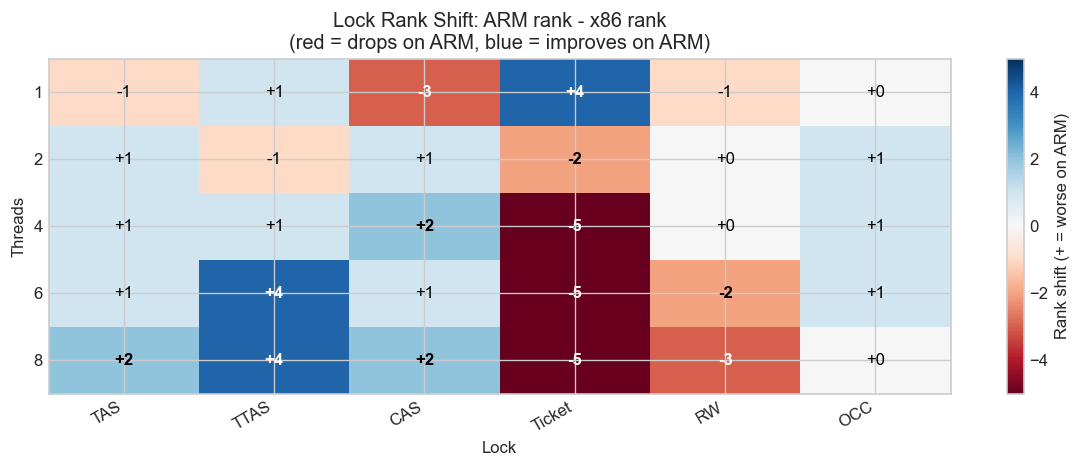

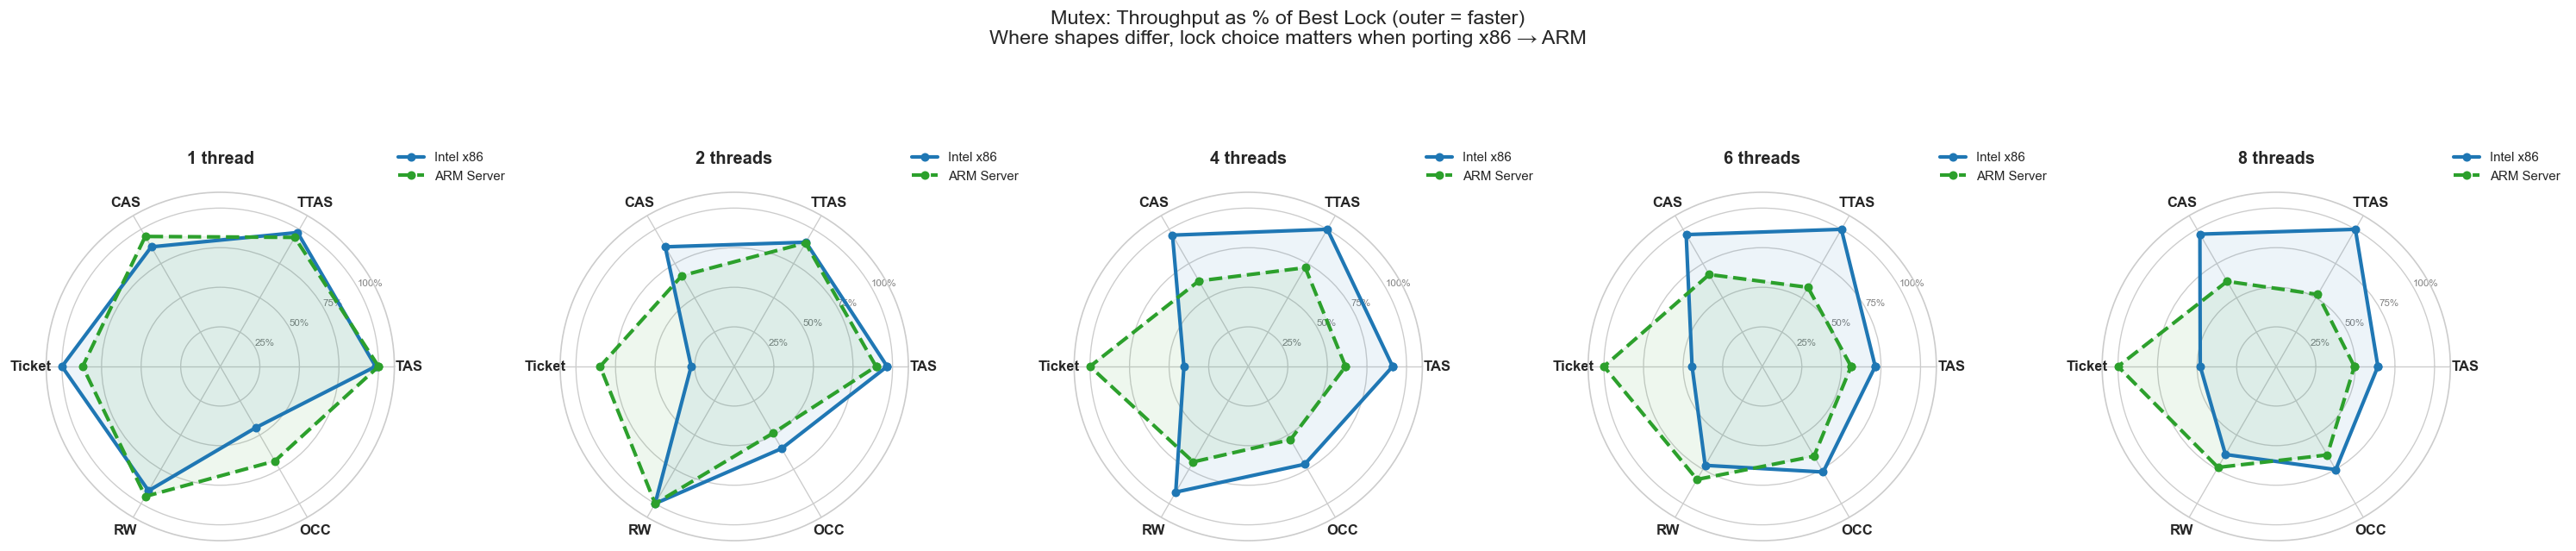


Rank tables (1 = fastest):

Intel x86:


,TAS,TTAS,CAS,Ticket,RW,OCC
threads,,,,,,
1,2,3,5,1,4,6
2,2,3,4,6,1,5
4,4,1,2,6,3,5
6,5,1,2,6,4,3
8,4,1,2,6,5,3



ARM Server:


,TAS,TTAS,CAS,Ticket,RW,OCC
threads,,,,,,
1,1,4,2,5,3,6
2,3,2,5,4,1,6
4,5,2,4,1,3,6
6,6,5,3,1,2,4
8,6,5,4,1,2,3


In [65]:
# Build rank tables for each platform
ranks = {}
for plat in ['x86', 'arm']:
    sub = g_mutex[g_mutex['platform'] == plat]
    tbl = sub.pivot(index='threads', columns='lock', values='ops_m_mean')
    tbl = tbl[[l for l in LOCK_ORDER if l in tbl.columns]]
    ranks[plat] = tbl.rank(axis=1, ascending=False).astype(int)

# Rank difference heatmap (kept for reference)
rank_diff = ranks['arm'] - ranks['x86']
rank_diff.columns = [LOCK_LABELS.get(c, c) for c in rank_diff.columns]

fig, ax = plt.subplots(figsize=(10, 4))
abs_max = max(abs(rank_diff.values.min()), abs(rank_diff.values.max()), 1)
im = ax.imshow(rank_diff.values, aspect='auto', cmap='RdBu', vmin=-abs_max, vmax=abs_max)
ax.set_xticks(range(len(rank_diff.columns)))
ax.set_xticklabels(rank_diff.columns, rotation=30, ha='right')
ax.set_yticks(range(len(rank_diff.index)))
ax.set_yticklabels(rank_diff.index)
ax.set_xlabel('Lock'); ax.set_ylabel('Threads')
ax.set_title('Lock Rank Shift: ARM rank - x86 rank\n(red = drops on ARM, blue = improves on ARM)')
for i in range(len(rank_diff.index)):
    for j in range(len(rank_diff.columns)):
        v = rank_diff.values[i, j]
        ax.text(j, i, f'{v:+d}', ha='center', va='center', fontsize=10,
                fontweight='bold' if abs(v) >= 2 else 'normal',
                color='white' if abs(v) >= abs_max * 0.6 else 'black')
fig.colorbar(im, ax=ax, label='Rank shift (+ = worse on ARM)')
fig.tight_layout()
plt.show()

# ── Radar: normalized throughput (% of best lock) per platform ────────────────
# Each spoke = one lock. Value = throughput as % of the best lock at that thread count.
# 100% at the rim = that lock IS the best choice. Overlaying both platforms shows
# where ARM and x86 agree or disagree on which locks are strong.

mutex_locks_present = [l for l in LOCK_ORDER if l in ranks['x86'].columns]
n_spokes = len(mutex_locks_present)
spoke_angles = np.linspace(0, 2 * np.pi, n_spokes, endpoint=False).tolist()
spoke_angles += spoke_angles[:1]

# Build normalized throughput (fraction of best) per platform & thread count
norm_tput = {}
for plat in ['x86', 'arm']:
    sub = g_mutex[g_mutex['platform'] == plat]
    tbl = sub.pivot(index='threads', columns='lock', values='ops_m_mean')
    tbl = tbl[[l for l in mutex_locks_present]]
    norm_tput[plat] = tbl.div(tbl.max(axis=1), axis=0) * 100  # as percentage

n_threads = len(SHARED_THREADS)
fig, axes = plt.subplots(1, n_threads, figsize=(5 * n_threads, 5.5),
                         subplot_kw=dict(polar=True))
if n_threads == 1:
    axes = [axes]

for ax, t in zip(axes, SHARED_THREADS):
    for plat, color, ls, lw in [('x86', PLAT_COLORS['x86'], '-', 2.5),
                                 ('arm', PLAT_COLORS['arm'], '--', 2.5)]:
        if t not in norm_tput[plat].index:
            continue
        vals = [norm_tput[plat].loc[t, l] for l in mutex_locks_present]
        vals += vals[:1]
        ax.plot(spoke_angles, vals, color=color, linestyle=ls, linewidth=lw,
                label=PLAT_LABELS[plat], marker='o', markersize=5)
        ax.fill(spoke_angles, vals, color=color, alpha=0.08)

    ax.set_xticks(spoke_angles[:-1])
    ax.set_xticklabels([LOCK_LABELS[l] for l in mutex_locks_present], fontsize=10, fontweight='bold')
    ax.set_ylim(0, 110)
    ax.set_yticks([25, 50, 75, 100])
    ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=7, color='gray')
    ax.set_title(f'{t} thread{"s" if t > 1 else ""}', fontsize=12, pad=20, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right', bbox_to_anchor=(1.35, 1.15))
    ax.set_rlabel_position(30)

fig.suptitle('Mutex: Throughput as % of Best Lock (outer = faster)\n'
             'Where shapes differ, lock choice matters when porting x86 → ARM',
             fontsize=14, y=1.08)
fig.tight_layout()
plt.show()

print('\nRank tables (1 = fastest):')
for plat in ['x86', 'arm']:
    r = ranks[plat].copy()
    r.columns = [LOCK_LABELS.get(c, c) for c in r.columns]
    print(f'\n{PLAT_LABELS[plat]}:')
    display(r)

## 13. Per-Platform Normalized Throughput — Lock performance relative to best lock

Each lock's throughput divided by the *best lock's throughput on that platform at that thread count*.

/var/folders/bx/qxvsk6k93_g7w59yp71ff7tw0000gn/T/ipykernel_28684/3075679297.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


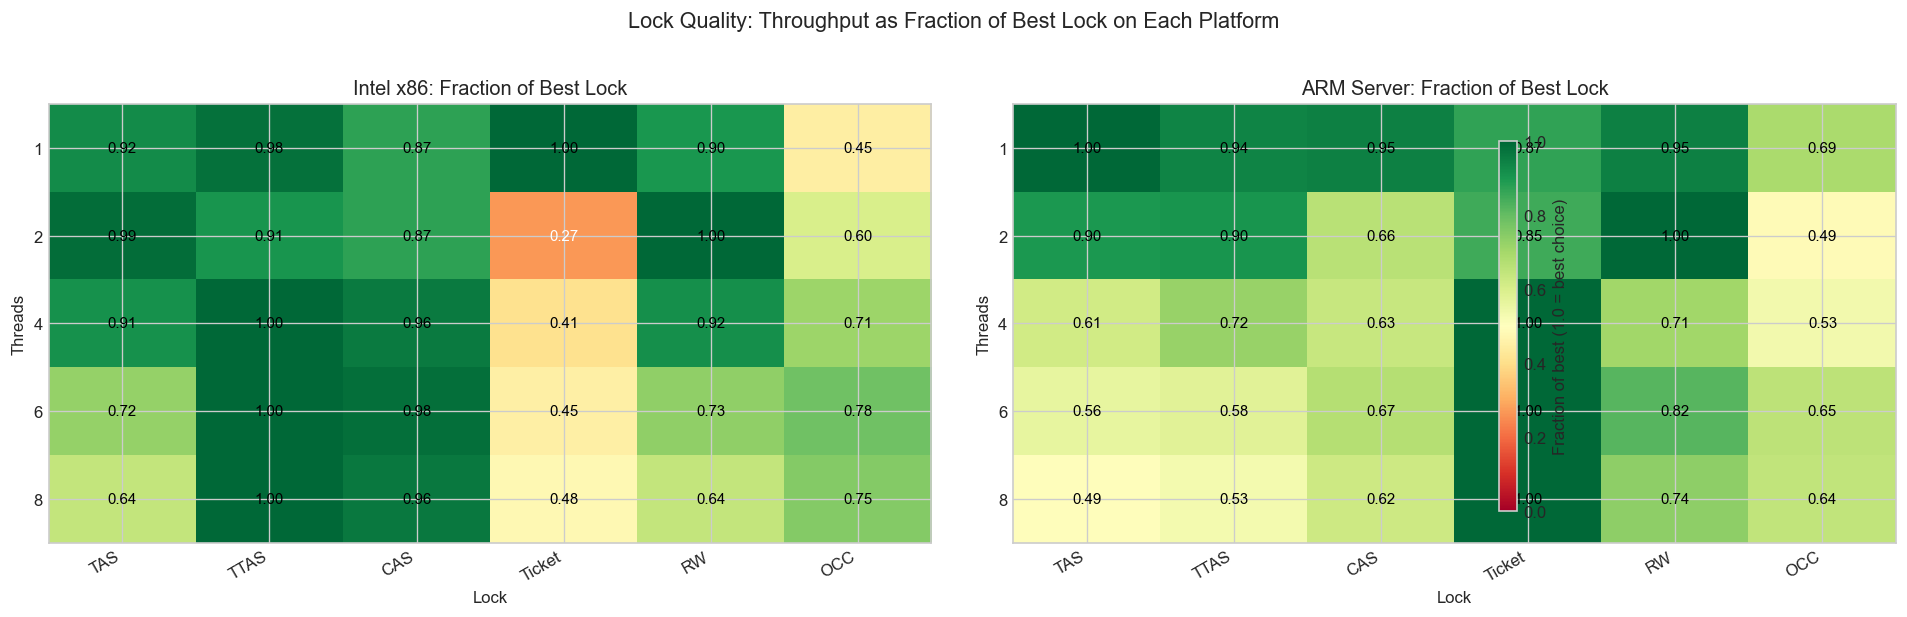

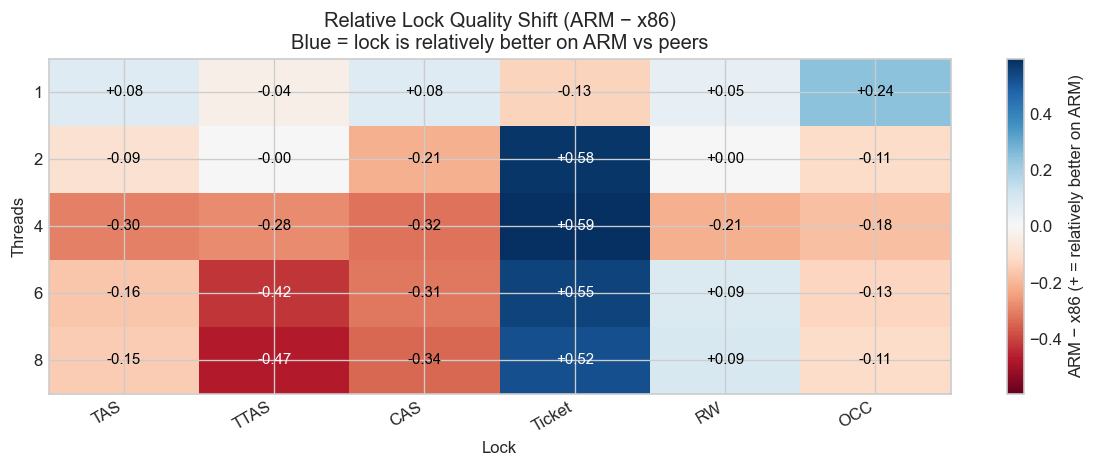


Normalized throughput (fraction of best lock per platform):

Intel x86:


,TAS,TTAS,CAS,Ticket,RW,OCC
threads,,,,,,
1,0.923,0.977,0.872,1.000,0.899,0.447
2,0.987,0.906,0.872,0.269,1.000,0.598
4,0.912,1.000,0.958,0.407,0.916,0.713
6,0.724,1.000,0.983,0.450,0.732,0.781
8,0.642,1.000,0.965,0.480,0.643,0.752



ARM Server:


,TAS,TTAS,CAS,Ticket,RW,OCC
threads,,,,,,
1,1.000,0.941,0.948,0.870,0.948,0.690
2,0.897,0.903,0.663,0.849,1.000,0.488
4,0.615,0.720,0.635,1.000,0.707,0.534
6,0.561,0.577,0.670,1.000,0.819,0.654
8,0.494,0.528,0.624,1.000,0.736,0.645


In [18]:
# Normalize each lock to best-in-class on that platform at that thread count
norm_frames = {}
for plat in ['x86', 'arm']:
    sub = g_mutex[g_mutex['platform'] == plat]
    tbl = sub.pivot(index='threads', columns='lock', values='ops_m_mean')
    tbl = tbl[[l for l in LOCK_ORDER if l in tbl.columns]]
    # Divide each row by its max
    norm = tbl.div(tbl.max(axis=1), axis=0)
    norm.columns = [LOCK_LABELS.get(c, c) for c in norm.columns]
    norm_frames[plat] = norm

# Side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, plat in zip(axes, ['x86', 'arm']):
    heat = norm_frames[plat]
    im = ax.imshow(heat.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1.0)
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels(heat.columns, rotation=30, ha='right')
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(heat.index)
    ax.set_xlabel('Lock')
    ax.set_ylabel('Threads')
    ax.set_title(f'{PLAT_LABELS[plat]}: Fraction of Best Lock')
    
    for i in range(len(heat.index)):
        for j in range(len(heat.columns)):
            v = heat.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                        color='white' if v < 0.4 else 'black')

fig.colorbar(im, ax=axes, label='Fraction of best (1.0 = best choice)', shrink=0.8)
fig.suptitle('Lock Quality: Throughput as Fraction of Best Lock on Each Platform', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

# How much does the relative quality of each lock differ between platforms?
# diff = (norm_arm - norm_x86): positive means lock is relatively better on ARM
norm_diff = norm_frames['arm'] - norm_frames['x86']
fig, ax = plt.subplots(figsize=(10, 4))
abs_max = max(abs(norm_diff.values.min()), abs(norm_diff.values.max()), 0.1)
im = ax.imshow(norm_diff.values, aspect='auto', cmap='RdBu', vmin=-abs_max, vmax=abs_max)
ax.set_xticks(range(len(norm_diff.columns)))
ax.set_xticklabels(norm_diff.columns, rotation=30, ha='right')
ax.set_yticks(range(len(norm_diff.index)))
ax.set_yticklabels(norm_diff.index)
ax.set_xlabel('Lock')
ax.set_ylabel('Threads')
ax.set_title('Relative Lock Quality Shift (ARM − x86)\nBlue = lock is relatively better on ARM vs peers')

for i in range(len(norm_diff.index)):
    for j in range(len(norm_diff.columns)):
        v = norm_diff.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center', fontsize=9,
                    color='white' if abs(v) > abs_max * 0.6 else 'black')

fig.colorbar(im, ax=ax, label='ARM − x86 (+ = relatively better on ARM)')
fig.tight_layout()
plt.show()

# Table view
print('\nNormalized throughput (fraction of best lock per platform):')
for plat in ['x86', 'arm']:
    print(f'\n{PLAT_LABELS[plat]}:')
    display(norm_frames[plat].round(3))

## 14. RW Workload — Normalized Variance & Lock Rankings under Mixed Reads

Same relative analysis but for the RW workload (OCC vs RW lock) at different read percentages.
This matters for index porting because B-tree / hash index workloads are read-heavy.

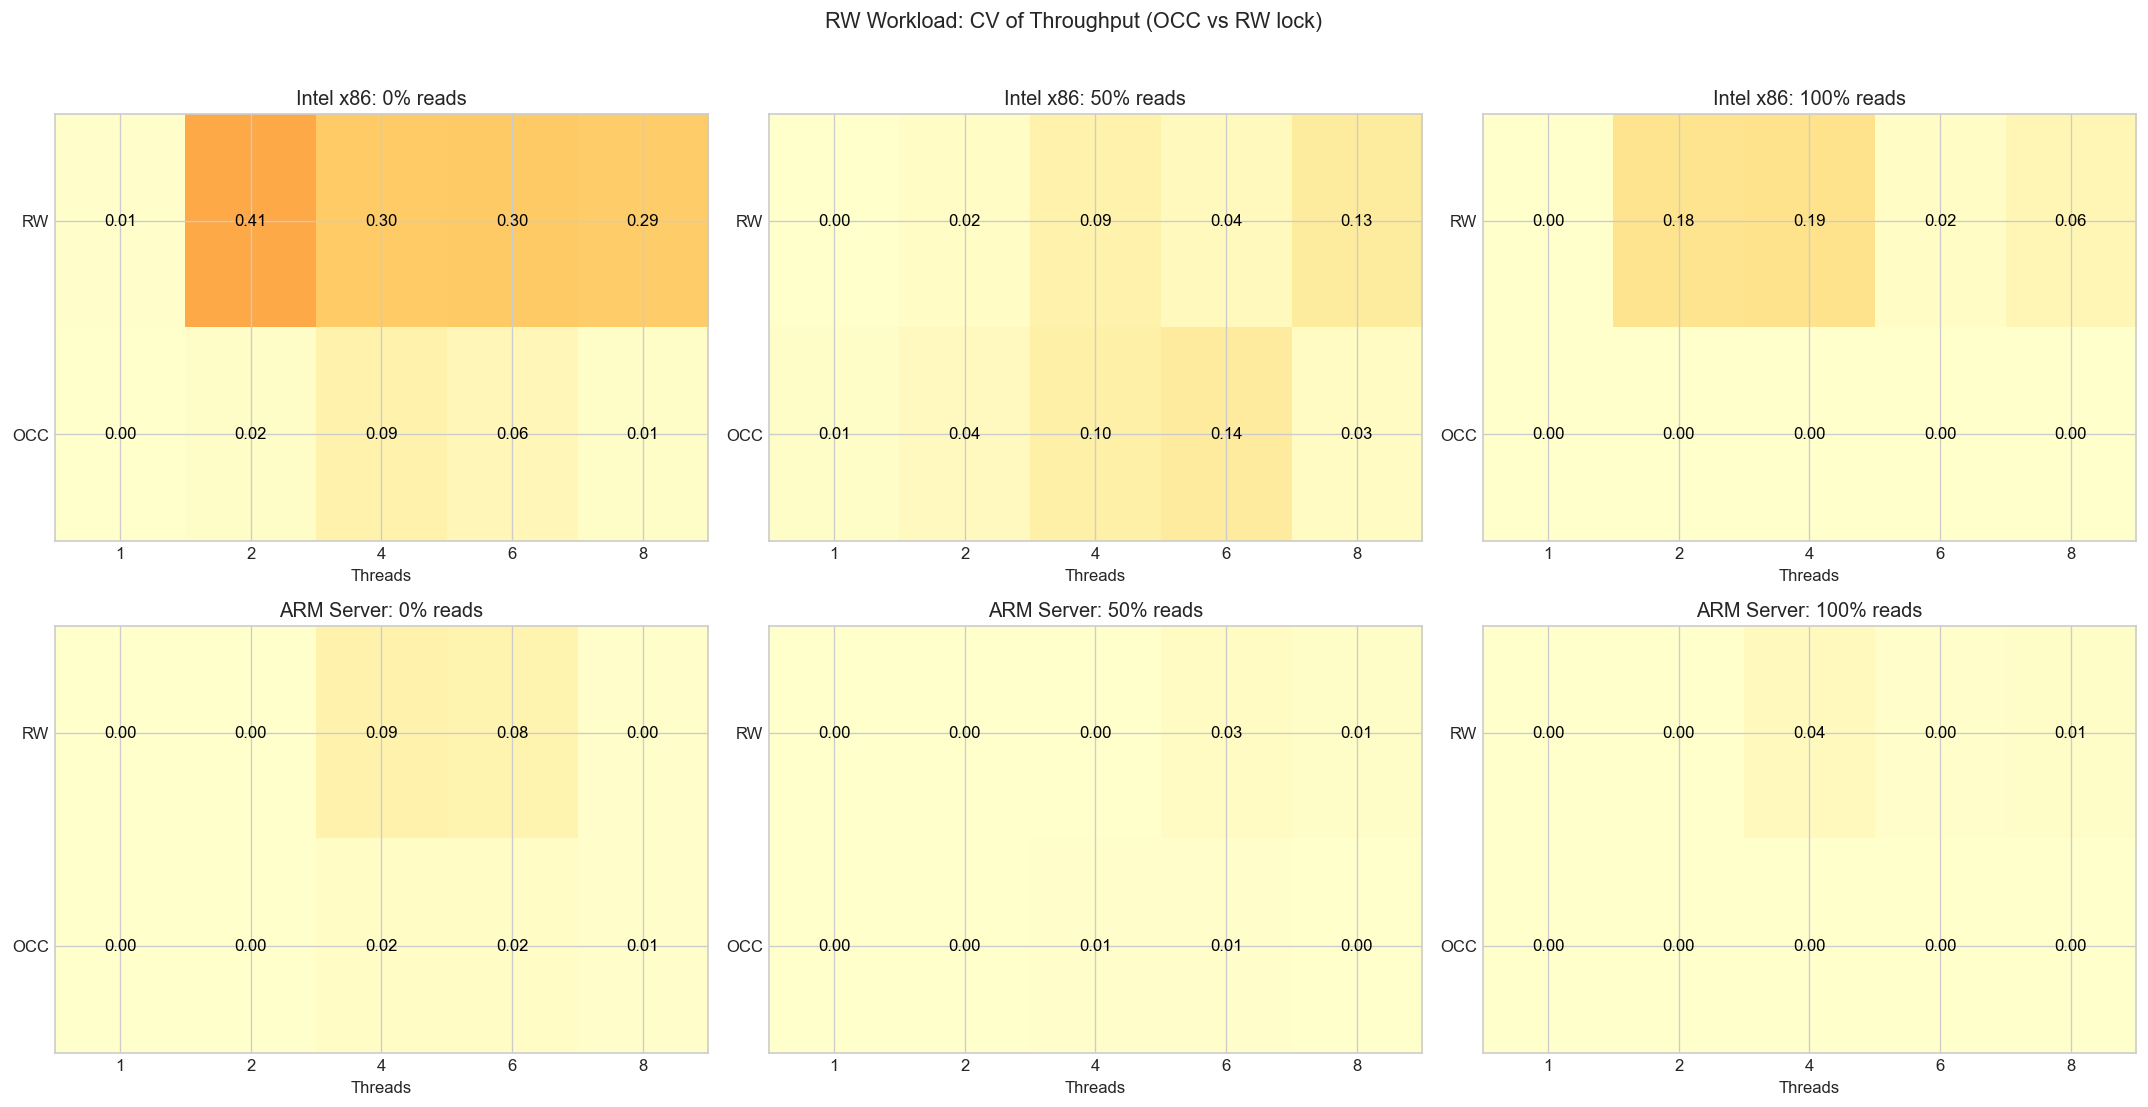

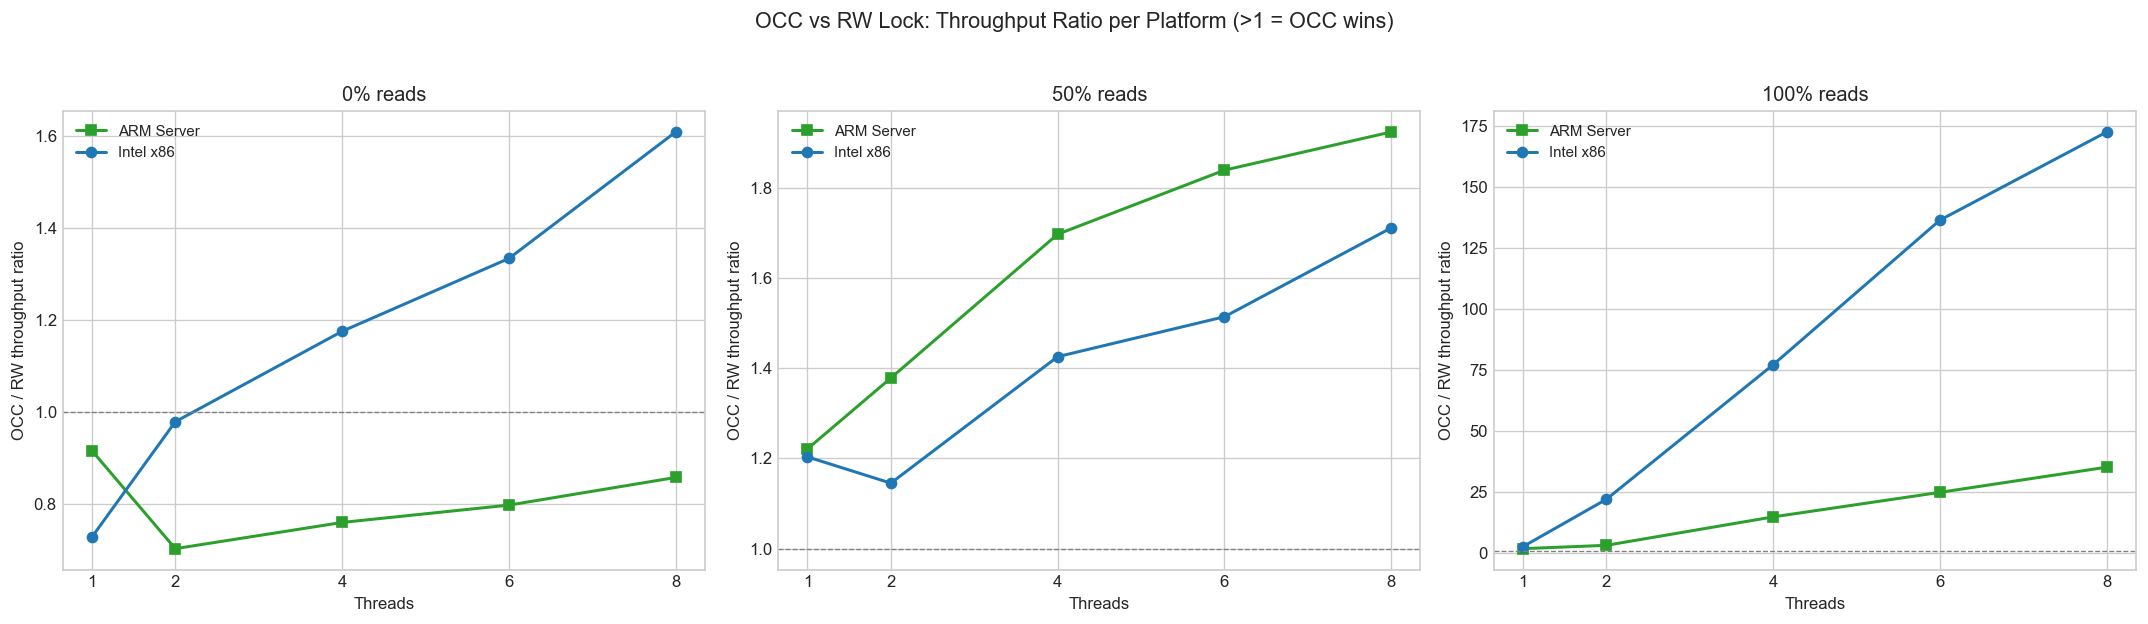

In [66]:
# RW workload: CV and ARM/x86 ratio per read_pct
g_rw_cv = g_rw.copy()
g_rw_cv['cv'] = g_rw_cv['ops_m_std'] / g_rw_cv['ops_m_mean']

# CV heatmaps per platform, faceted by read_pct
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for col, read_pct in enumerate(READ_PCTS):
    for row, plat in enumerate(['x86', 'arm']):
        ax = axes[row, col]
        sub = g_rw_cv[(g_rw_cv['platform'] == plat) & (g_rw_cv['read_pct'] == read_pct)]
        heat = sub.pivot(index='lock', columns='threads', values='cv')
        heat = heat.reindex([l for l in ['rw', 'occ'] if l in heat.index])
        heat.index = [LOCK_LABELS.get(l, l) for l in heat.index]
        
        im = ax.imshow(heat.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1.0)
        ax.set_xticks(range(len(heat.columns)))
        ax.set_xticklabels([int(c) for c in heat.columns])
        ax.set_yticks(range(len(heat.index)))
        ax.set_yticklabels(heat.index)
        ax.set_xlabel('Threads')
        ax.set_title(f'{PLAT_LABELS[plat]}: {read_pct}% reads')
        
        for i in range(len(heat.index)):
            for j in range(len(heat.columns)):
                v = heat.values[i, j]
                if not np.isnan(v):
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10,
                            color='white' if v > 0.5 else 'black')

fig.suptitle('RW Workload: CV of Throughput (OCC vs RW lock)', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

# OCC advantage over RW: ratio on each platform at each read_pct
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, read_pct in zip(axes, READ_PCTS):
    for plat in ['arm', 'x86']:
        sub_occ = g_rw[(g_rw['platform'] == plat) & (g_rw['lock'] == 'occ') & (g_rw['read_pct'] == read_pct)]
        sub_rw = g_rw[(g_rw['platform'] == plat) & (g_rw['lock'] == 'rw') & (g_rw['read_pct'] == read_pct)]
        merged = sub_occ[['threads', 'ops_m_mean']].merge(
            sub_rw[['threads', 'ops_m_mean']], on='threads', suffixes=('_occ', '_rw'))
        merged['occ_over_rw'] = merged['ops_m_mean_occ'] / merged['ops_m_mean_rw']
        ax.plot(merged['threads'], merged['occ_over_rw'],
                label=PLAT_LABELS[plat], color=PLAT_COLORS[plat],
                marker=PLAT_MARKER[plat], linewidth=1.8)
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(f'{read_pct}% reads')
    ax.set_xlabel('Threads')
    ax.set_ylabel('OCC / RW throughput ratio')
    ax.set_xticks(SHARED_THREADS)
    ax.legend(fontsize=9)

fig.suptitle('OCC vs RW Lock: Throughput Ratio per Platform (>1 = OCC wins)', fontsize=13, y=1.03)
fig.tight_layout()
plt.show()

## 14b. OCC vs RW Lock vs RCU — Radar Comparison under Read/Write Workloads

Radar charts comparing OCC, RW lock, and RCU throughput across platforms
at each read percentage (0%, 50%, 100%). Each spoke is a thread count.
Value = throughput as % of the best primitive at that thread count.
Shows which synchronization strategy wins for each read/write mix on each arch.

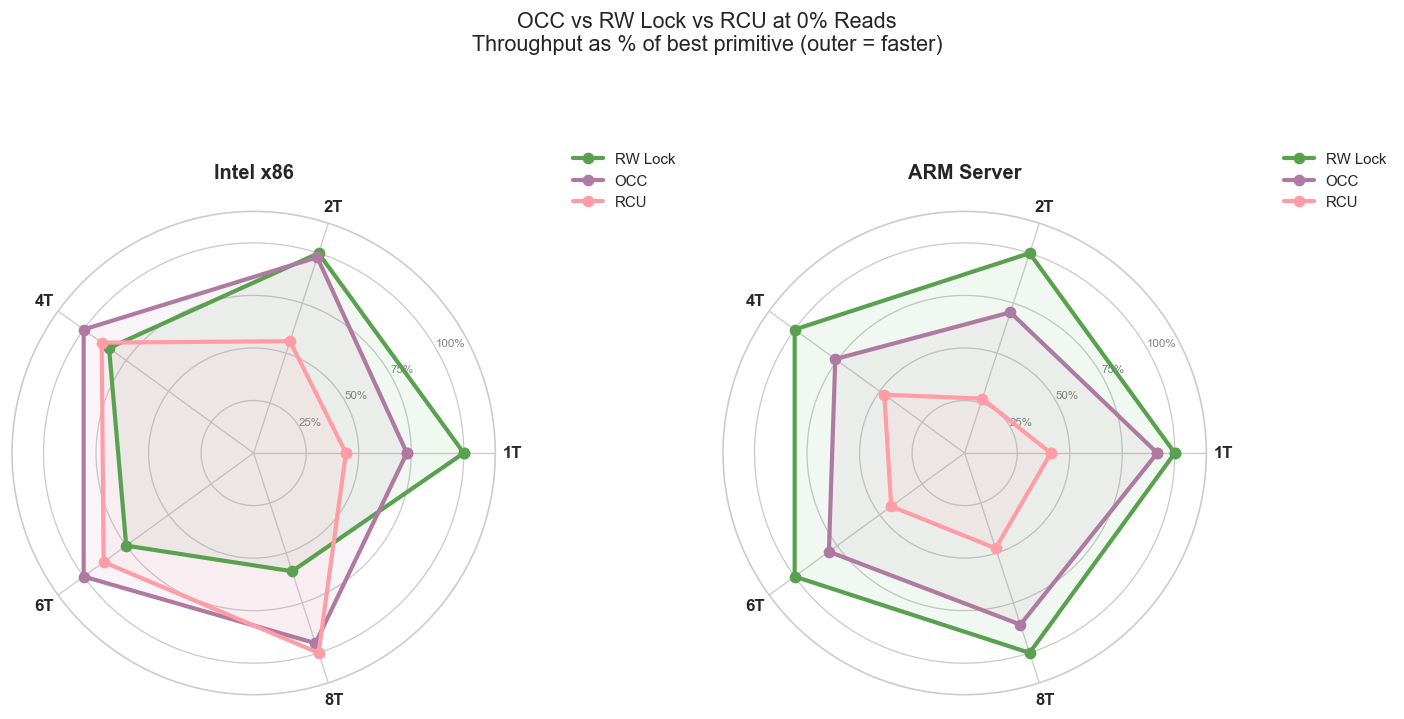

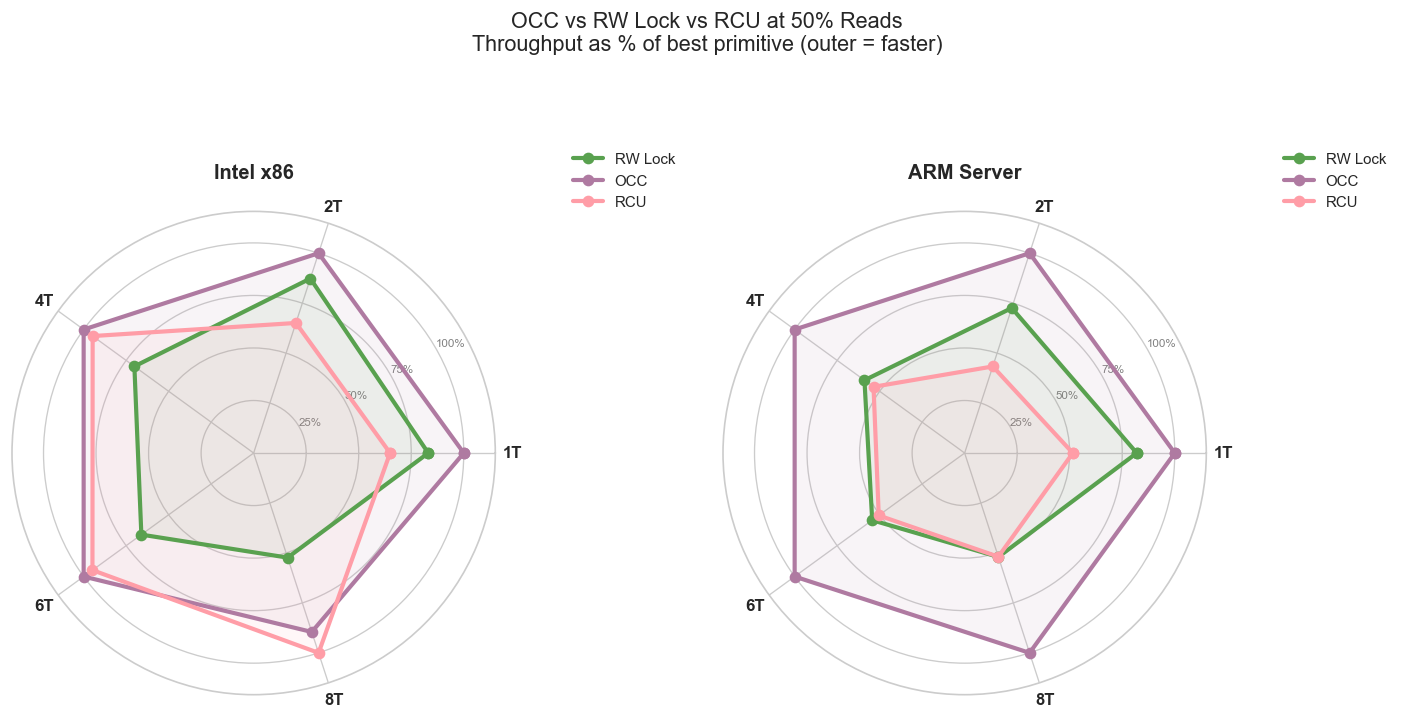

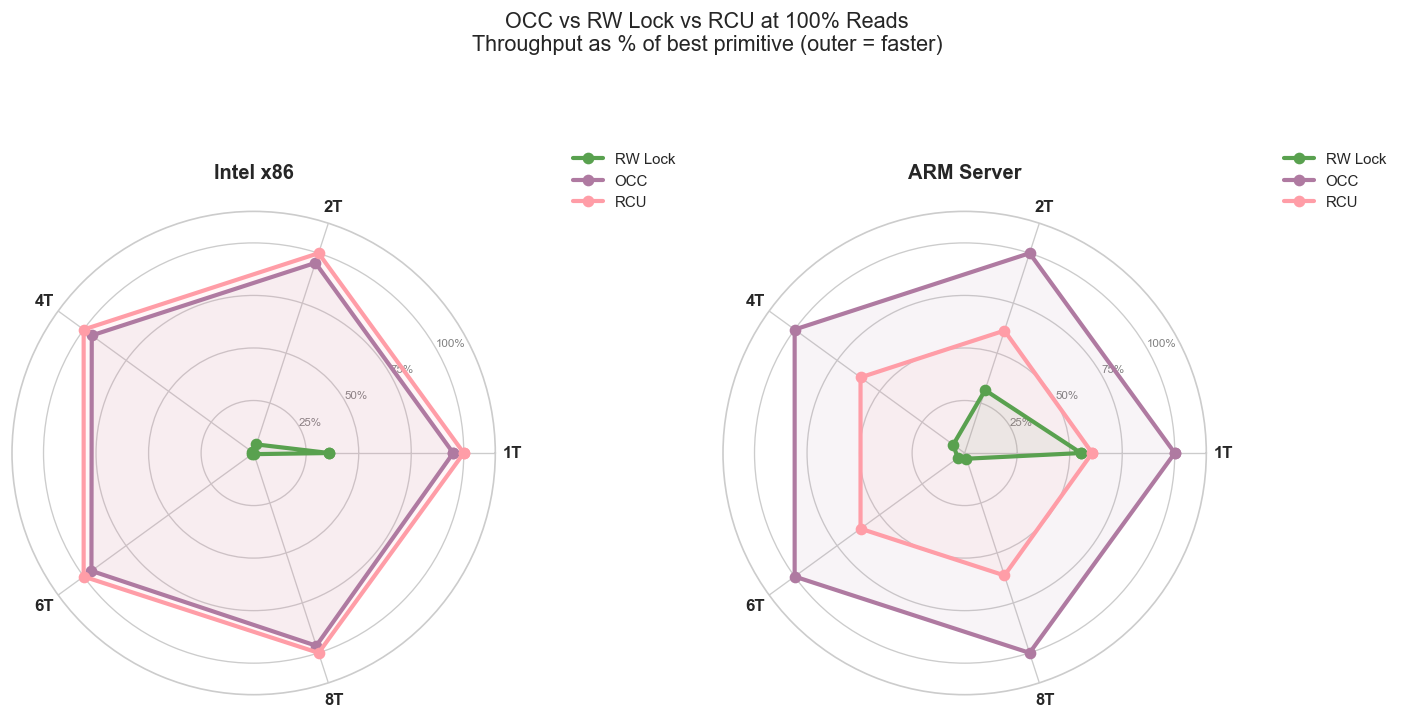


Best primitive per scenario:


platform         ARM Server Intel x86
read_pct threads                     
0        1          RW Lock   RW Lock
         2          RW Lock   RW Lock
         4          RW Lock       OCC
         6          RW Lock       OCC
         8          RW Lock       RCU
50       1              OCC       OCC
         2              OCC       OCC
         4              OCC       OCC
         6              OCC       OCC
         8              OCC       RCU
100      1              OCC       RCU
         2              OCC       RCU
         4              OCC       RCU
         6              OCC       RCU
         8              OCC       RCU

In [67]:
# OCC vs RW lock (rw workload) + RCU (rcu workload): radar comparison
# Combine rw-workload (occ, rw) and rcu-workload (rcu) for the same read_pct/threads

rw_rcu_data = all_df[
    (all_df['threads'].isin(SHARED_THREADS)) &
    (
        ((all_df['workload'] == 'rw') & (all_df['lock'].isin(['occ', 'rw']))) |
        ((all_df['workload'] == 'rcu') & (all_df['lock'] == 'rcu'))
    )
].copy()
# Use lock name as the primitive label
g_rw_rcu = agg(rw_rcu_data, ['platform', 'lock', 'read_pct', 'threads'])

PRIM_ORDER = ['rw', 'occ', 'rcu']
PRIM_LABELS = {'rw': 'RW Lock', 'occ': 'OCC', 'rcu': 'RCU'}

spoke_labels = [f'{int(t)}T' for t in SHARED_THREADS]
n_spokes_rw = len(SHARED_THREADS)
spoke_angles_rw = np.linspace(0, 2 * np.pi, n_spokes_rw, endpoint=False).tolist()
spoke_angles_rw += spoke_angles_rw[:1]

for read_pct in READ_PCTS:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), subplot_kw=dict(polar=True))

    for ax, plat in zip(axes, ['x86', 'arm']):
        sub = g_rw_rcu[(g_rw_rcu['platform'] == plat) & (g_rw_rcu['read_pct'] == read_pct)]
        if sub.empty:
            continue

        # Pivot: rows=threads, cols=lock
        tbl = sub.pivot(index='threads', columns='lock', values='ops_m_mean')
        tbl = tbl.reindex(columns=[l for l in PRIM_ORDER if l in tbl.columns])
        tbl = tbl.reindex(SHARED_THREADS)

        # Normalize to best primitive at each thread count
        norm = tbl.div(tbl.max(axis=1), axis=0) * 100

        for lock in [l for l in PRIM_ORDER if l in norm.columns]:
            vals = norm[lock].tolist()
            vals += vals[:1]
            ax.plot(spoke_angles_rw, vals, color=LOCK_COLORS[lock], linewidth=2.5,
                    label=PRIM_LABELS[lock], marker='o', markersize=6)
            ax.fill(spoke_angles_rw, vals, color=LOCK_COLORS[lock], alpha=0.08)

        ax.set_xticks(spoke_angles_rw[:-1])
        ax.set_xticklabels(spoke_labels, fontsize=10, fontweight='bold')
        ax.set_ylim(0, 115)
        ax.set_yticks([25, 50, 75, 100])
        ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=7, color='gray')
        ax.set_title(f'{PLAT_LABELS[plat]}', fontsize=12, pad=20, fontweight='bold')
        ax.legend(fontsize=9, loc='upper right', bbox_to_anchor=(1.4, 1.15))
        ax.set_rlabel_position(30)

    fig.suptitle(f'OCC vs RW Lock vs RCU at {read_pct}% Reads\n'
                 f'Throughput as % of best primitive (outer = faster)',
                 fontsize=13, y=1.08)
    fig.tight_layout()
    plt.show()

# Summary table: which primitive wins at each (platform, read_pct, threads)
print('\nBest primitive per scenario:')
winner_rows = []
for read_pct in READ_PCTS:
    for plat in ['x86', 'arm']:
        sub = g_rw_rcu[(g_rw_rcu['platform'] == plat) & (g_rw_rcu['read_pct'] == read_pct)]
        if sub.empty:
            continue
        tbl = sub.pivot(index='threads', columns='lock', values='ops_m_mean')
        for t in SHARED_THREADS:
            if t in tbl.index:
                best_lock = tbl.loc[t].idxmax()
                best_val = tbl.loc[t].max()
                winner_rows.append({
                    'platform': PLAT_LABELS[plat], 'read_pct': int(read_pct),
                    'threads': int(t), 'best': PRIM_LABELS.get(best_lock, best_lock),
                    'Mops': round(best_val, 1)
                })
winner_df = pd.DataFrame(winner_rows)
display(winner_df.pivot_table(index=['read_pct', 'threads'], columns='platform',
                              values='best', aggfunc='first'))

## 15. Fairness-Weighted Throughput — Combined Score for Porting Decisions

A lock that's fast but unfair may cause starvation in concurrent index operations.
Combined score = throughput_normalized * fairness.
Plotted per platform to show which lock gives the best throughput-fairness trade-off on each arch.

/var/folders/bx/qxvsk6k93_g7w59yp71ff7tw0000gn/T/ipykernel_28684/3424881203.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


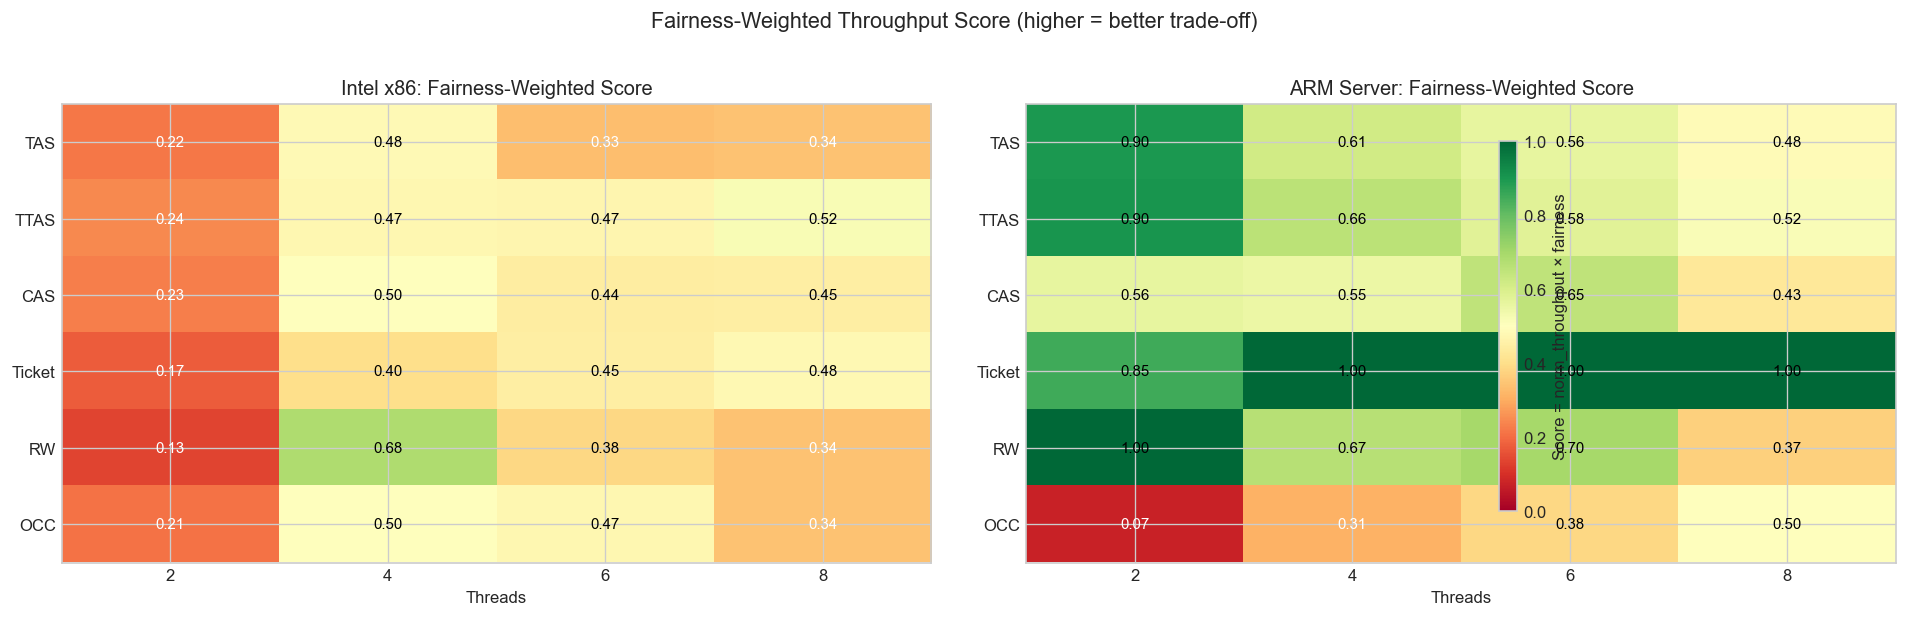

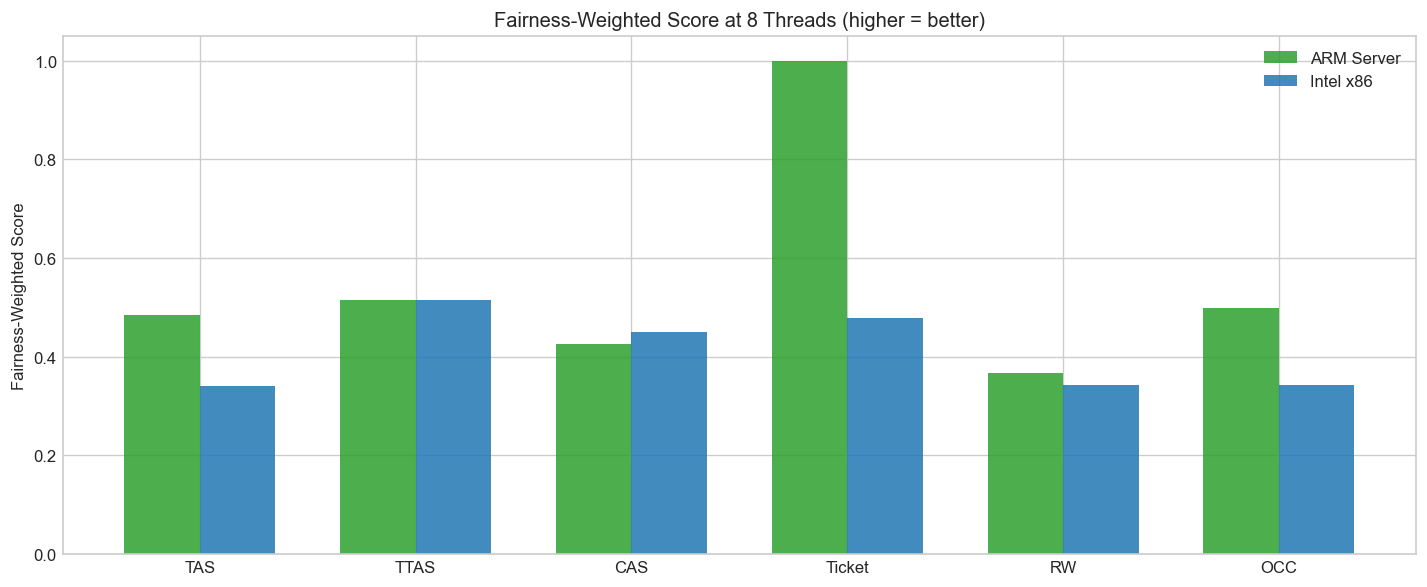

In [20]:
# Fairness-weighted throughput: normalized_throughput * fairness_ratio
# Only for multi-threaded (fairness at 1T is always 1.0)
g_fwt = g_mutex[g_mutex['threads'] > 1].copy()

# Normalize throughput per (platform, threads) to best lock
for (plat, t), grp in g_fwt.groupby(['platform', 'threads']):
    best = grp['ops_m_mean'].max()
    g_fwt.loc[grp.index, 'norm_tput'] = grp['ops_m_mean'] / best

g_fwt['fwt_score'] = g_fwt['norm_tput'] * g_fwt['fair_mean']

# Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, plat in zip(axes, ['x86', 'arm']):
    sub = g_fwt[g_fwt['platform'] == plat]
    heat = sub.pivot(index='lock', columns='threads', values='fwt_score')
    heat = heat.reindex([l for l in LOCK_ORDER if l in heat.index])
    heat.index = [LOCK_LABELS.get(l, l) for l in heat.index]
    
    im = ax.imshow(heat.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1.0)
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels([int(c) for c in heat.columns])
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(heat.index)
    ax.set_xlabel('Threads')
    ax.set_title(f'{PLAT_LABELS[plat]}: Fairness-Weighted Score')
    
    for i in range(len(heat.index)):
        for j in range(len(heat.columns)):
            v = heat.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                        color='white' if v < 0.35 else 'black')

fig.colorbar(im, ax=axes, label='Score = norm_throughput × fairness', shrink=0.8)
fig.suptitle('Fairness-Weighted Throughput Score (higher = better trade-off)', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

# Bar chart at highest shared thread count (8T)
fwt_8t = g_fwt[g_fwt['threads'] == 8].copy()
locks_present = [l for l in LOCK_ORDER if l in fwt_8t['lock'].unique()]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(locks_present))
w = 0.35
for i, plat in enumerate(['arm', 'x86']):
    sub = fwt_8t[fwt_8t['platform'] == plat].set_index('lock').reindex(locks_present)
    ax.bar(x + i * w, sub['fwt_score'], w,
           label=PLAT_LABELS[plat], color=PLAT_COLORS[plat], alpha=0.85)

ax.set_xticks(x + w / 2)
ax.set_xticklabels([LOCK_LABELS[l] for l in locks_present])
ax.set_ylabel('Fairness-Weighted Score')
ax.set_title('Fairness-Weighted Score at 8 Threads (higher = better)')
ax.legend()
fig.tight_layout()
plt.show()

## 16. Latency Variance & Per-Run Distribution — Raw Sample Spread

Box plots of raw per-run throughput samples for each lock at key thread counts.
Shows whether outliers / bimodal behaviour exists on either platform.

/var/folders/bx/qxvsk6k93_g7w59yp71ff7tw0000gn/T/ipykernel_28684/3180763360.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.6)
/var/folders/bx/qxvsk6k93_g7w59yp71ff7tw0000gn/T/ipykernel_28684/3180763360.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.6)
/var/folders/bx/qxvsk6k93_g7w59yp71ff7tw0000gn/T/ipykernel_28684/3180763360.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.6)
/var/folders/bx/qxvsk6k93_g7w59yp7

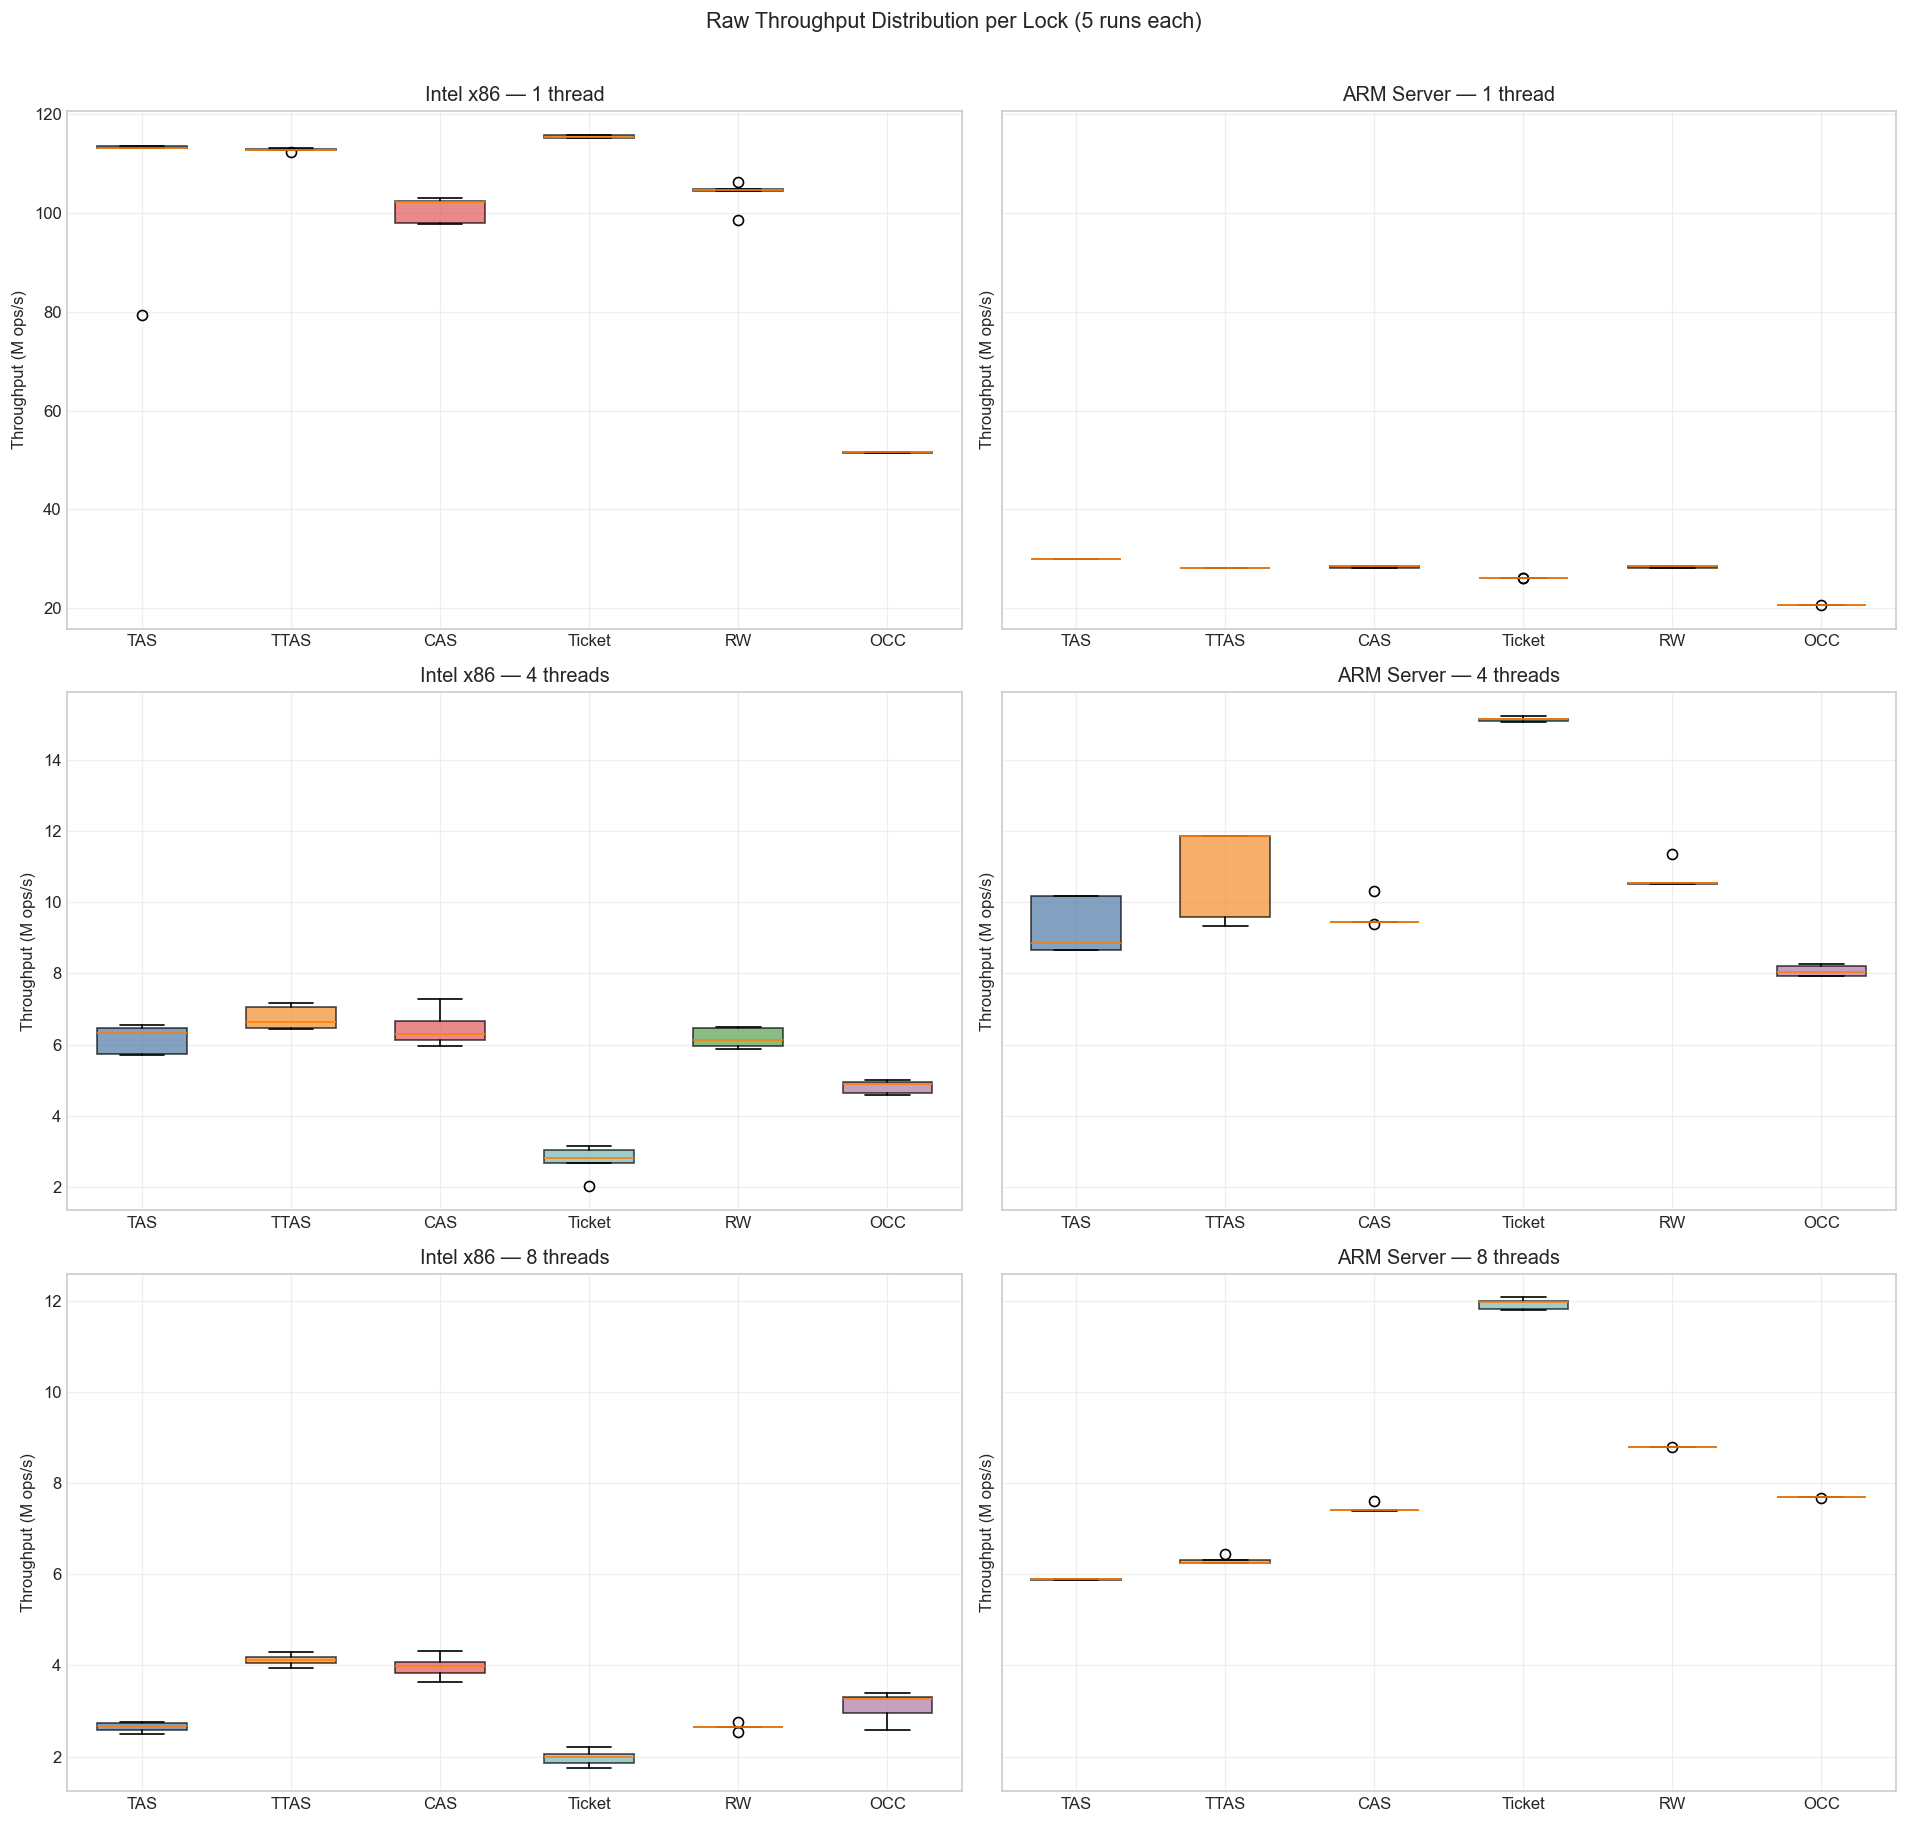

/var/folders/bx/qxvsk6k93_g7w59yp71ff7tw0000gn/T/ipykernel_28684/3180763360.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.6)
/var/folders/bx/qxvsk6k93_g7w59yp71ff7tw0000gn/T/ipykernel_28684/3180763360.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.6)
/var/folders/bx/qxvsk6k93_g7w59yp71ff7tw0000gn/T/ipykernel_28684/3180763360.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.6)
/var/folders/bx/qxvsk6k93_g7w59yp7

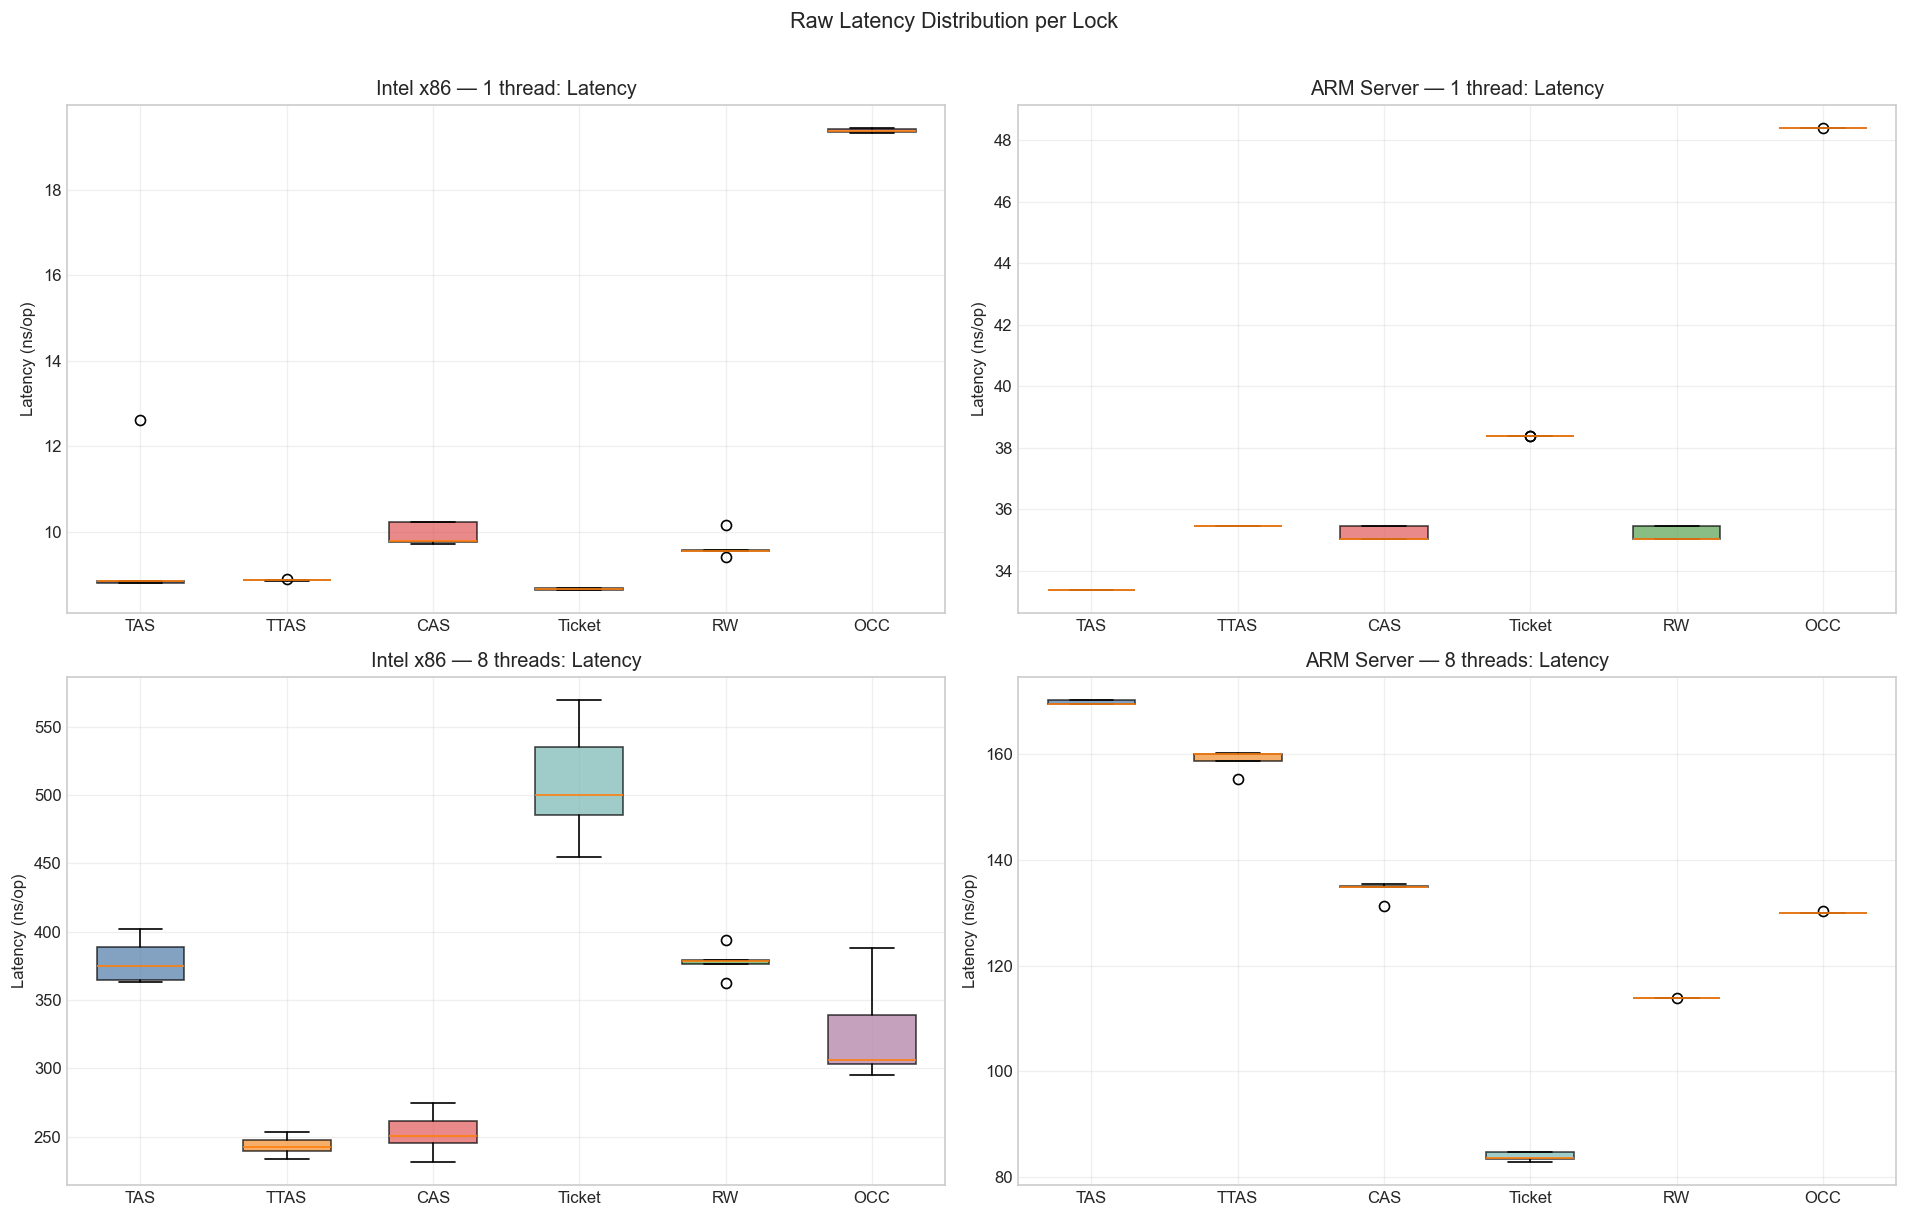

In [21]:
# Box plots of raw throughput per run at key thread counts
KEY_THREADS = [1, 4, 8]

fig, axes = plt.subplots(len(KEY_THREADS), 2, figsize=(16, 5 * len(KEY_THREADS)), sharey='row')

for row, t in enumerate(KEY_THREADS):
    for col, plat in enumerate(['x86', 'arm']):
        ax = axes[row, col]
        sub = mutex[(mutex['threads'] == t) & (mutex['platform'] == plat)]
        # Order locks consistently
        lock_order = [l for l in LOCK_ORDER if l in sub['lock'].unique()]
        data = [sub[sub['lock'] == l]['ops_m'].values for l in lock_order]
        labels = [LOCK_LABELS[l] for l in lock_order]
        
        bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.6)
        for patch, lock in zip(bp['boxes'], lock_order):
            patch.set_facecolor(LOCK_COLORS[lock])
            patch.set_alpha(0.7)
        
        ax.set_ylabel('Throughput (M ops/s)')
        ax.set_title(f'{PLAT_LABELS[plat]} — {t} thread{"s" if t > 1 else ""}')
        ax.grid(True, alpha=0.3)

fig.suptitle('Raw Throughput Distribution per Lock (5 runs each)', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

# Latency (ns/op) box plots at 1T and 8T
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for row, t in enumerate([1, 8]):
    for col, plat in enumerate(['x86', 'arm']):
        ax = axes[row, col]
        sub = mutex[(mutex['threads'] == t) & (mutex['platform'] == plat)]
        lock_order = [l for l in LOCK_ORDER if l in sub['lock'].unique()]
        data = [sub[sub['lock'] == l]['ns_op'].values for l in lock_order]
        labels = [LOCK_LABELS[l] for l in lock_order]
        
        bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.6)
        for patch, lock in zip(bp['boxes'], lock_order):
            patch.set_facecolor(LOCK_COLORS[lock])
            patch.set_alpha(0.7)
        
        ax.set_ylabel('Latency (ns/op)')
        ax.set_title(f'{PLAT_LABELS[plat]} — {t} thread{"s" if t > 1 else ""}: Latency')
        ax.grid(True, alpha=0.3)

fig.suptitle('Raw Latency Distribution per Lock', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 17. Throughput Gap — Pairwise lock comparison across platforms

For each pair of locks, compute the ratio of their throughput on ARM vs x86.
If lock A beats lock B by 2x on x86 but only 1.2x on ARM, the performance gap narrows —
important for deciding whether to keep the same lock when porting.

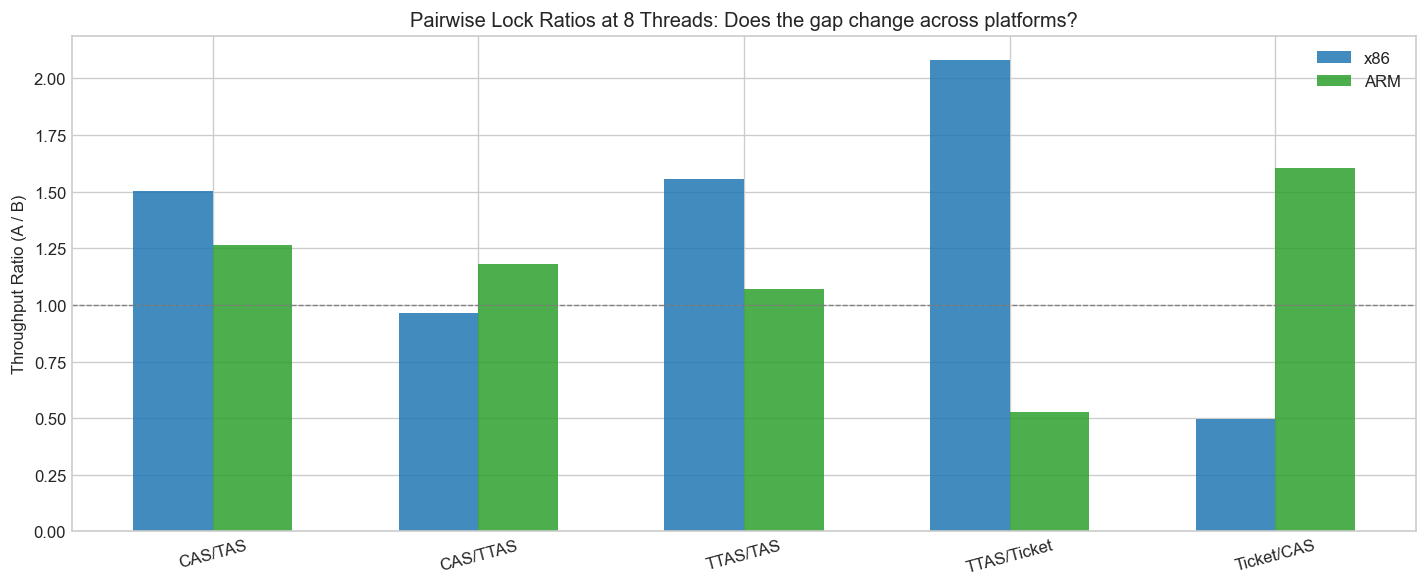

Pairwise ratios (>1 = numerator lock is faster):


platform,arm,x86,gap_shift
pair,,,
CAS/TAS,1.264,1.502,-0.238
CAS/TTAS,1.182,0.965,0.218
TTAS/TAS,1.069,1.557,-0.488
TTAS/Ticket,0.528,2.083,-1.555
Ticket/CAS,1.603,0.498,1.105


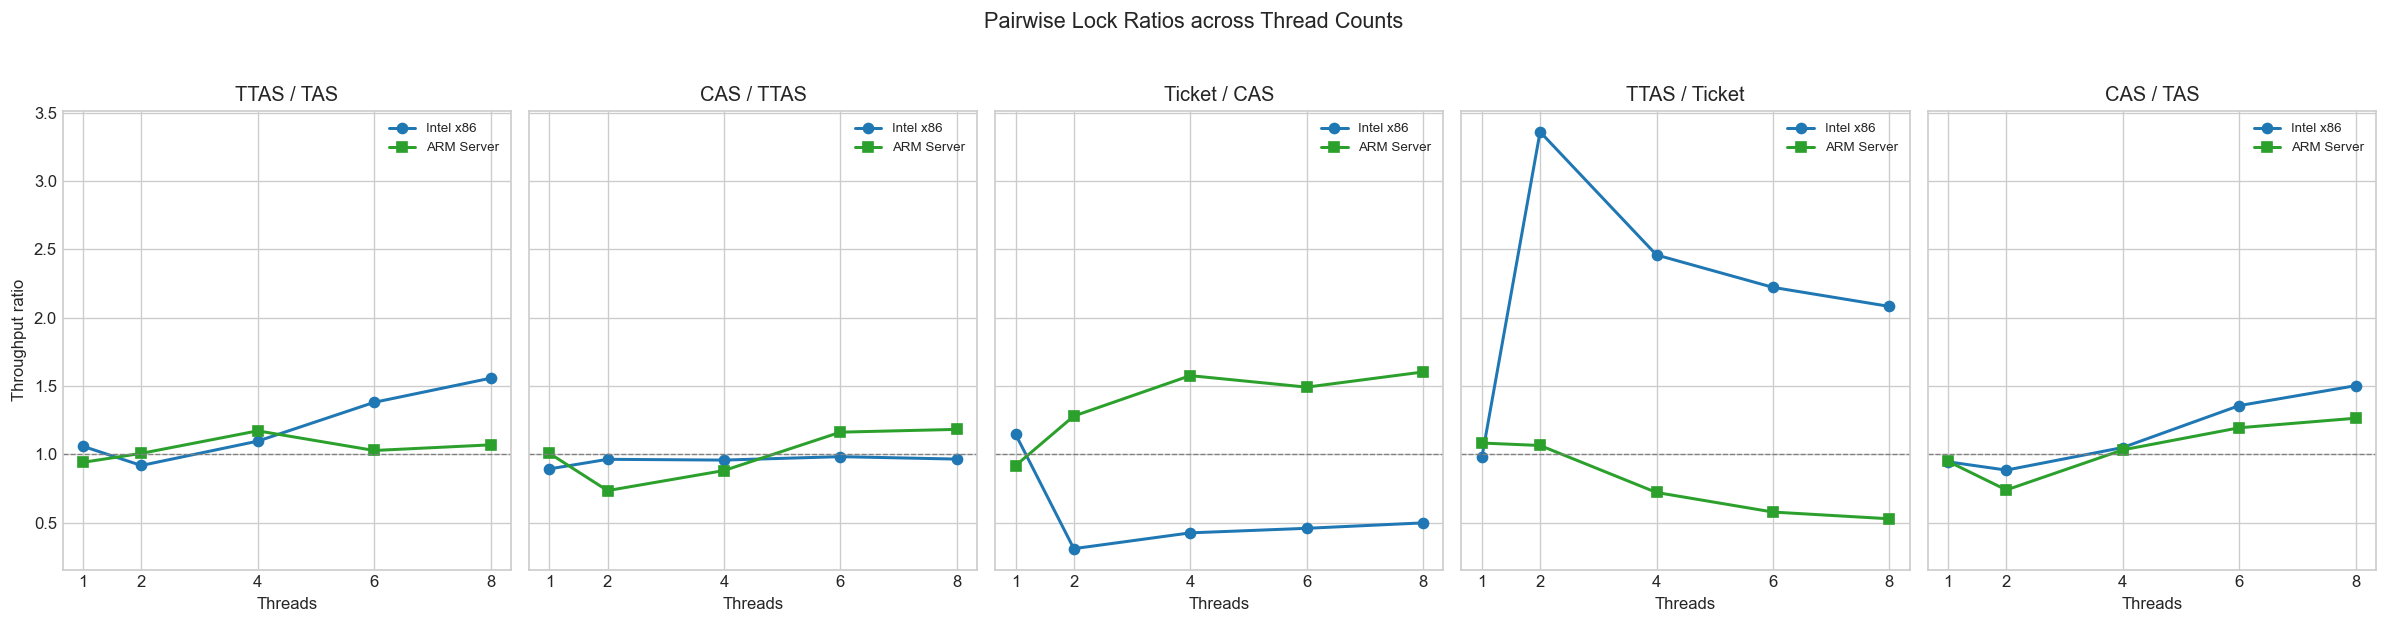

In [22]:
# Pairwise throughput ratios at 8T: for key lock pairs
import itertools

PAIRS = [('ttas', 'tas'), ('cas', 'ttas'), ('ticket', 'cas'), ('ttas', 'ticket'), ('cas', 'tas')]
t8 = g_mutex[g_mutex['threads'] == 8].set_index(['platform', 'lock'])['ops_m_mean']

rows = []
for a, b in PAIRS:
    for plat in ['x86', 'arm']:
        try:
            ratio = t8.loc[(plat, a)] / t8.loc[(plat, b)]
            rows.append({'pair': f'{LOCK_LABELS[a]}/{LOCK_LABELS[b]}', 'platform': plat, 'ratio': ratio})
        except KeyError:
            pass

pair_df = pd.DataFrame(rows)
pair_pivot = pair_df.pivot(index='pair', columns='platform', values='ratio')
pair_pivot['gap_shift'] = pair_pivot['arm'] - pair_pivot['x86']

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(pair_pivot))
w = 0.3
ax.bar(x - w/2, pair_pivot['x86'], w, label='x86', color=PLAT_COLORS['x86'], alpha=0.85)
ax.bar(x + w/2, pair_pivot['arm'], w, label='ARM', color=PLAT_COLORS['arm'], alpha=0.85)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(pair_pivot.index, rotation=15)
ax.set_ylabel('Throughput Ratio (A / B)')
ax.set_title('Pairwise Lock Ratios at 8 Threads: Does the gap change across platforms?')
ax.legend()
fig.tight_layout()
plt.show()

print('Pairwise ratios (>1 = numerator lock is faster):')
display(pair_pivot.round(3))

# Comprehensive: all pairwise at all thread counts
fig, axes = plt.subplots(1, len(PAIRS), figsize=(4 * len(PAIRS), 5), sharey=True)
for ax, (a, b) in zip(axes, PAIRS):
    for plat in ['x86', 'arm']:
        sub_a = g_mutex[(g_mutex['platform'] == plat) & (g_mutex['lock'] == a)].set_index('threads')['ops_m_mean']
        sub_b = g_mutex[(g_mutex['platform'] == plat) & (g_mutex['lock'] == b)].set_index('threads')['ops_m_mean']
        ratio = sub_a / sub_b
        ax.plot(ratio.index, ratio.values,
                label=PLAT_LABELS[plat], color=PLAT_COLORS[plat],
                marker=PLAT_MARKER[plat], linewidth=1.8)
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(f'{LOCK_LABELS[a]} / {LOCK_LABELS[b]}')
    ax.set_xlabel('Threads')
    ax.set_xticks(SHARED_THREADS)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Throughput ratio')
fig.suptitle('Pairwise Lock Ratios across Thread Counts', fontsize=13, y=1.03)
fig.tight_layout()
plt.show()

## 18. Normalized Fairness Variance — CV of Fairness Ratio

High CV in fairness means the lock's fairness is unpredictable across runs.
Combined with throughput CV, this gives a full picture of lock stability on each platform.

/var/folders/bx/qxvsk6k93_g7w59yp71ff7tw0000gn/T/ipykernel_28684/3925484630.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


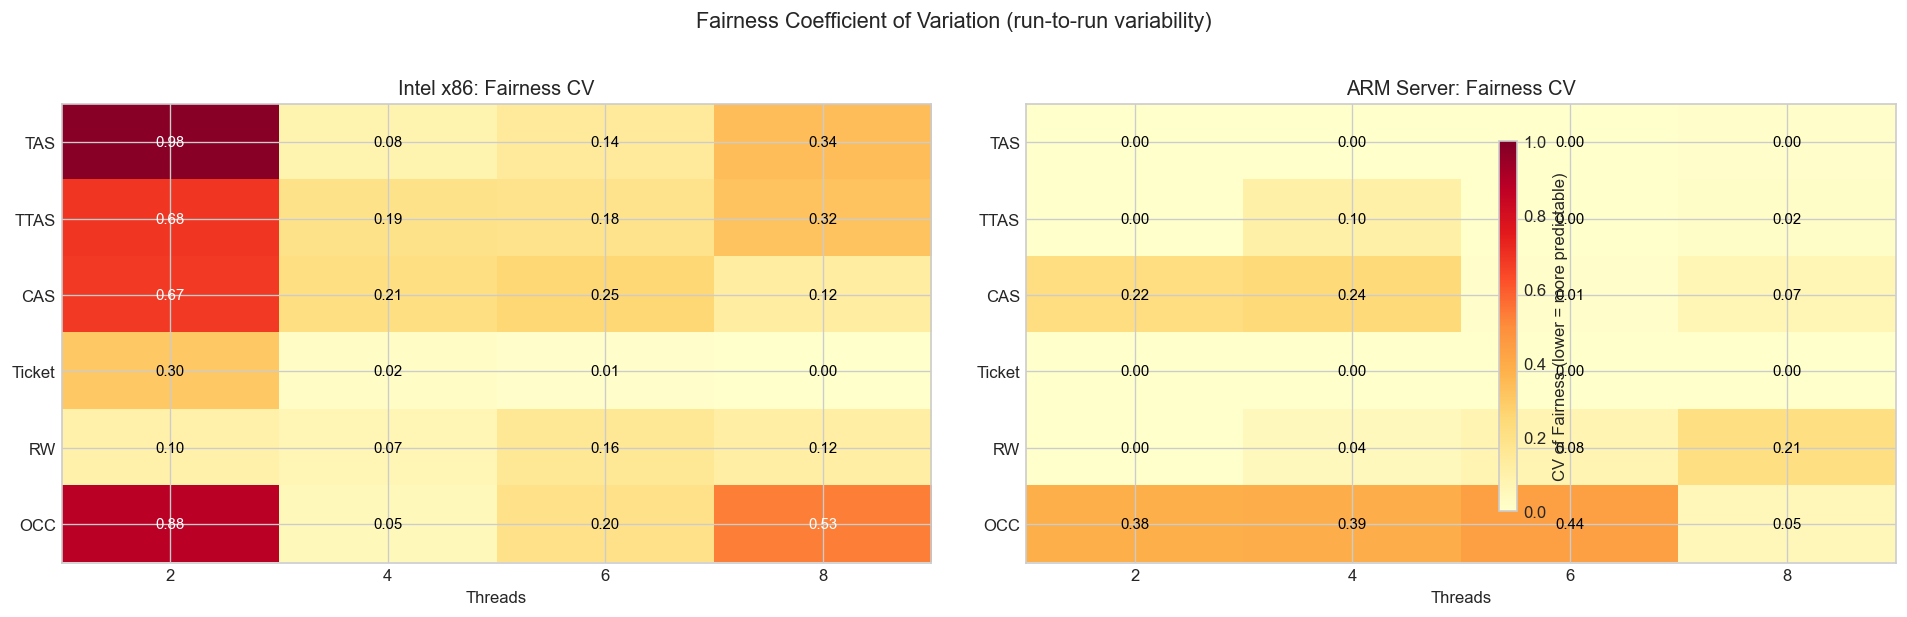

/var/folders/bx/qxvsk6k93_g7w59yp71ff7tw0000gn/T/ipykernel_28684/3925484630.py:54: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.tight_layout()
/Users/andreipana/Desktop/Research Project/lockbench/results/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


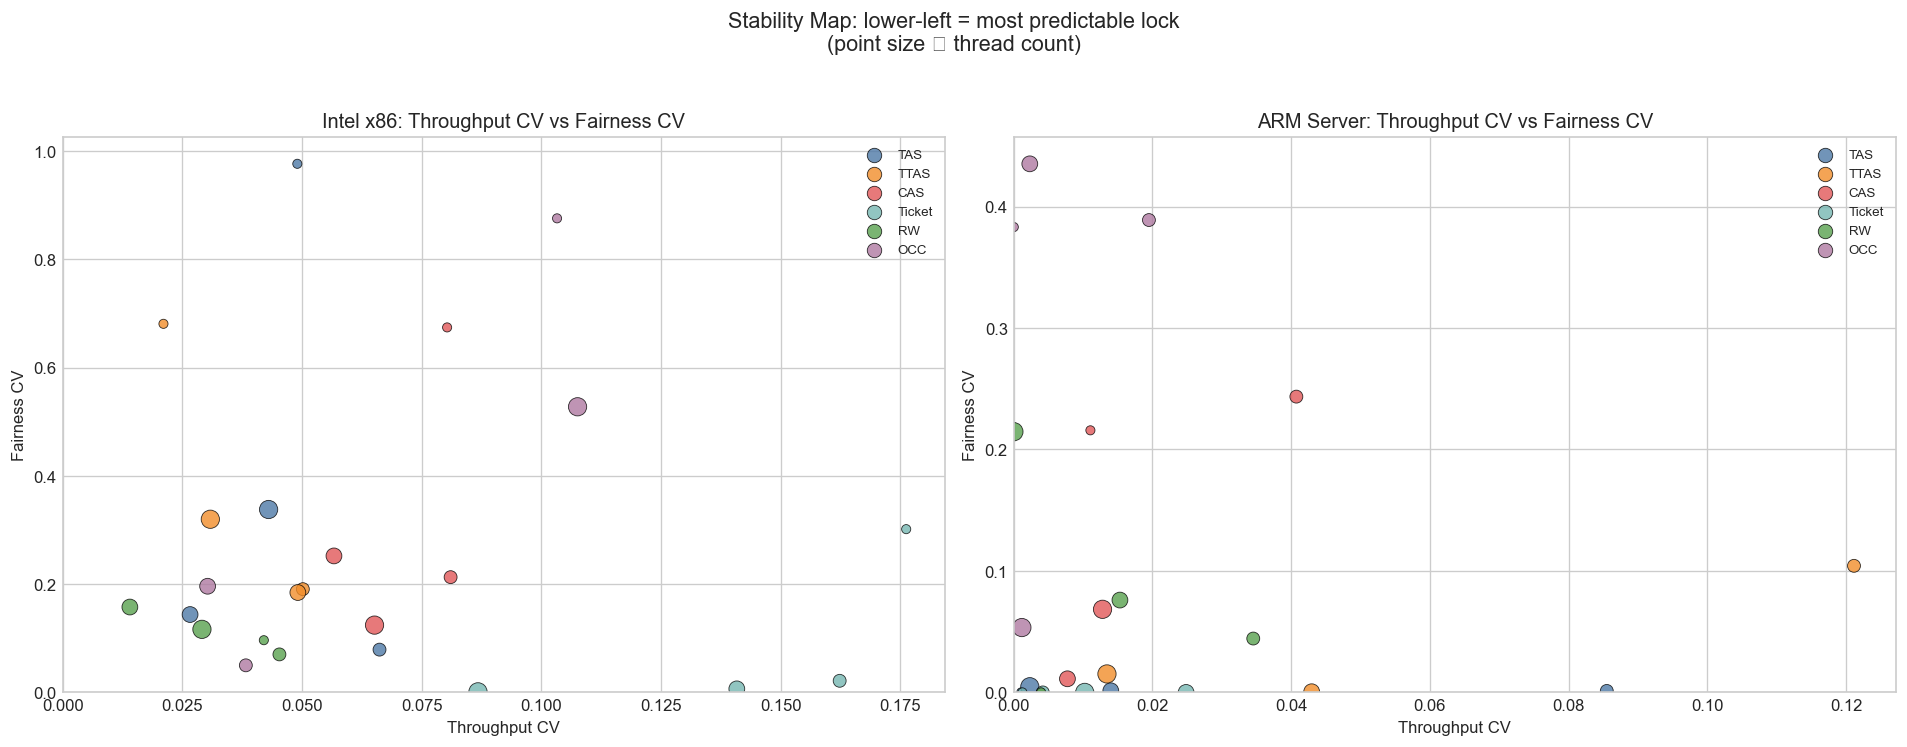

In [23]:
# CV of fairness ratio (multi-threaded only)
g_fair_cv = g_mutex[g_mutex['threads'] > 1].copy()
g_fair_cv['fair_cv'] = g_fair_cv['fair_std'] / g_fair_cv['fair_mean']

# Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, plat in zip(axes, ['x86', 'arm']):
    sub = g_fair_cv[g_fair_cv['platform'] == plat]
    heat = sub.pivot(index='lock', columns='threads', values='fair_cv')
    heat = heat.reindex([l for l in LOCK_ORDER if l in heat.index])
    heat.index = [LOCK_LABELS.get(l, l) for l in heat.index]
    
    im = ax.imshow(heat.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1.0)
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels([int(c) for c in heat.columns])
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(heat.index)
    ax.set_xlabel('Threads')
    ax.set_title(f'{PLAT_LABELS[plat]}: Fairness CV')
    
    for i in range(len(heat.index)):
        for j in range(len(heat.columns)):
            v = heat.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                        color='white' if v > 0.5 else 'black')

fig.colorbar(im, ax=axes, label='CV of Fairness (lower = more predictable)', shrink=0.8)
fig.suptitle('Fairness Coefficient of Variation (run-to-run variability)', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

# Scatter: throughput CV vs fairness CV (each point = one lock at one thread count)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, plat in zip(axes, ['x86', 'arm']):
    sub_cv = g_fair_cv[g_fair_cv['platform'] == plat].copy()
    sub_tput_cv = g_cv[g_cv['platform'] == plat][['lock', 'threads', 'cv']].rename(columns={'cv': 'tput_cv'})
    merged = sub_cv.merge(sub_tput_cv, on=['lock', 'threads'])
    
    for lock in [l for l in LOCK_ORDER if l in merged['lock'].unique()]:
        lsub = merged[merged['lock'] == lock]
        ax.scatter(lsub['tput_cv'], lsub['fair_cv'], 
                   label=LOCK_LABELS[lock], color=LOCK_COLORS[lock],
                   s=lsub['threads'] * 15, alpha=0.8, edgecolors='k', linewidths=0.5)
    
    ax.set_xlabel('Throughput CV')
    ax.set_ylabel('Fairness CV')
    ax.set_title(f'{PLAT_LABELS[plat]}: Throughput CV vs Fairness CV')
    ax.legend(fontsize=8)
    ax.set_xlim(0, None)
    ax.set_ylim(0, None)

fig.suptitle('Stability Map: lower-left = most predictable lock\n(point size ∝ thread count)', fontsize=13, y=1.03)
fig.tight_layout()
plt.show()